In [2]:
import numpy as np
from datetime import datetime 

# from synoptic import TimeSeries
import easysnowdata as esd 

from typing import List, Set

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextily as ctx
import xarray as xr
import rioxarray as rio
from xrspatial import aspect
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

from pathlib import Path

import math
import gc
import os 

# Looking at short baseline flights over my study areas

I'm expecting three flights from RMNP and six flights from SLC. 

RMNP were all 7 day baselines while SLC had between 6 and 8 day baselines. 

In [40]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
slc = xr.open_zarr(data_dir + 'stacks/slc_box_swe')
slc_1x1 = xr.open_zarr(data_dir + 'stacks/slc_box_1x1_coh')
slc['coherence'] = slc_1x1['coherence']


t1_str = slc["pair"].str[:6]
t2_str = slc["pair"].str[7:]
# print(t1_str)
t1_formatted = "20" + t1_str.str[:2] + "-" + t1_str.str[2:4] + "-" + t1_str.str[4:]
t2_formatted = "20" + t2_str.str[:2] + "-" + t2_str.str[2:4] + "-" + t2_str.str[4:]
t1_dt = t1_formatted.astype("datetime64[s]")
t2_dt = t2_formatted.astype("datetime64[s]")
# print(t1_dt[0], t2_dt[0])
days_elapsed = (t2_dt - t1_dt) / np.timedelta64(1, "D")
# print(days_elapsed[0])
slc["temp_baseline"] = days_elapsed
slc = slc.sel(pair=(days_elapsed <= 8))

rmnp = xr.open_zarr(data_dir + 'stacks/rmnp_box_swe')

t1_str = rmnp["pair"].str[:6]
t2_str = rmnp["pair"].str[7:]
# print(t1_str)
t1_formatted = "20" + t1_str.str[:2] + "-" + t1_str.str[2:4] + "-" + t1_str.str[4:]
t2_formatted = "20" + t2_str.str[:2] + "-" + t2_str.str[2:4] + "-" + t2_str.str[4:]
t1_dt = t1_formatted.astype("datetime64[s]")
t2_dt = t2_formatted.astype("datetime64[s]")
# print(t1_dt[0], t2_dt[0])
days_elapsed = (t2_dt - t1_dt) / np.timedelta64(1, "D")
# print(days_elapsed[0])
rmnp["temp_baseline"] = days_elapsed
rmnp = rmnp.sel(pair=(days_elapsed <= 8))

print(f"RMNP number of pairs < 8 days: {len(rmnp['pair'])}")
for p in rmnp['pair'].values: 
    print(f"{p}: {rmnp.sel(pair=p)['temp_baseline'].values}")
print(f"SLC number of pairs < 8 days: {len(slc['pair'])}")
for p in slc['pair'].values: 
    print(f"{p}: {slc.sel(pair=p)['temp_baseline'].values}")

RMNP number of pairs < 8 days: 3
200212_200219: 7.0
210127_210203: 7.0
210303_210310: 7.0
SLC number of pairs < 8 days: 6
200213_200221: 8.0
210203_210210: 7.0
210223_210303: 8.0
210303_210310: 7.0
210310_210316: 6.0
210316_210322: 6.0


## Filter for physical parameters and cross-pol coherence 

In [41]:
inc_cutoff = 80
canopy_cutoff = 30
elev_quant = 60

In [42]:
def filter_data(data) : 
    single_year_pairs = [
        p for p in data.coords['pair'].values 
        if p[:2] == p[7:9]
    ]

    print(f'Filtering for {len(single_year_pairs)} single-year pairs.')
    data = data.sel(pair=single_year_pairs)

    print(f'Trimming to DEM.')
    data = data.where(data['elevation'].notnull())

    print(f'Filtering inc angle > {inc_cutoff}, canopy cover > {canopy_cutoff}, elev top {elev_quant}%.')
    condition = (data['incidence_angle'] < inc_cutoff) & \
                (data['canopy_2019'] < canopy_cutoff) & \
                (data['elevation'] > data['elevation'].quantile((100-elev_quant)/100))

    data = data.where(condition)

    return data

In [43]:
rmnp_good = filter_data(rmnp)
slc_good = filter_data(slc)

Filtering for 3 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 30, elev top 60%.
Filtering for 6 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 30, elev top 60%.


In [44]:
xpol_cutoff = 0.8
to_filter = rmnp_good 

In [45]:
def filter_and_plot_pairs(
    dataset: xr.Dataset, 
    coh_dir: Path, 
    cutoff: float
) -> xr.Dataset:
    """
    Pre-loads cross-pol coherences, applies a cutoff mask to reference and secondary
    flights, plots a 3-panel figure per pair, and returns the filtered dataset.
    
    Args:
        dataset: The target InSAR xarray.Dataset (e.g., rmnp_good).
        coh_dir: Pathlib object pointing to the directory of cross-pol tif files.
        cutoff: The cross-pol coherence threshold to apply to the mask.
        
    Returns:
        A fully masked xarray.Dataset concatenated back along the 'pair' dimension.
    """
    
    # 1. Extract unique dates to avoid redundant loading
    all_pairs: List[str] = dataset['pair'].values.tolist()
    unique_dates: Set[str] = set()
    for pair_name in all_pairs:
        # Utilizing character slicing as determined in our previous session
        unique_dates.add(pair_name[:6])  
        unique_dates.add(pair_name[7:13]) 

    # print(unique_dates)
        
    # 2. Pre-load all unique cross-pol rasters into a single datacube
    xpol_list: List[xr.DataArray] = []
    valid_dates: List[str] = []
    
    
    for date_str in sorted(list(unique_dates)):
        file_path_list = list(coh_dir.glob(f"*{date_str}*_crosspol_coh.tif"))
        # print(file_path_list)
        
        try:
            # Enforce API safety / File loader robustness
            if not file_path_list:
                raise FileNotFoundError(f"Missing cross-pol raster for date: {date_str}")
            
            # Squeeze band, assign the date as a coordinate, and append
            da = rio.open_rasterio(file_path_list[0]).squeeze('band', drop=True)
            da = da.assign_coords(date=date_str)
            xpol_list.append(da)
            valid_dates.append(date_str)
            
        except Exception as e:
            print(f"[ERROR] Failed to load cross-pol data for {date_str}: {e}")
            continue
            
    # Combine into a single cube and reproject ONCE to match target grid
    print(f"Reprojecting cross-pol datacube for {len(valid_dates)} unique flights...")
    xpol_cube = xr.concat(xpol_list, dim='date')
    xpol_cube = xpol_cube.rio.reproject_match(dataset)
    
    # 3. Iterate through pairs to mask and plot
    filtered_subsets: List[xr.Dataset] = []
    
    for pair_name in all_pairs:
        ref_date = pair_name[:6]
        sec_date = pair_name[7:13]
        
        # Fast in-memory selection
        xpol_ref = xpol_cube.sel(date=ref_date)
        xpol_sec = xpol_cube.sel(date=sec_date)
        
        # Calculate mask: both reference AND secondary flights must exceed cutoff
        crosspol_mask = (xpol_ref >= cutoff) & (xpol_sec >= cutoff)
        
        # Isolate the specific pair while retaining the 'pair' dimension
        target_pair = dataset.sel(pair=[pair_name])
        
        # Safely handle NoData / apply mask
        filtered_pair = target_pair.where(crosspol_mask)
        filtered_subsets.append(filtered_pair)
        
        # --- Plotting Subroutine ---
        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        
        target_pair['coherence'].plot(ax=axes[0], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[0].set_title(f"Reference Cross-Pol Coherence\n({ref_date})")
        axes[0].set_aspect('equal')

        # Ensure we are handling spatial constants / NaN display natively via xarray plotting
        xpol_ref.plot(ax=axes[1], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[1].set_title(f"Reference Cross-Pol Coherence\n({ref_date})")
        axes[1].set_aspect('equal')
        
        xpol_sec.plot(ax=axes[2], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[2].set_title(f"Secondary Cross-Pol Coherence\n({sec_date})")
        axes[2].set_aspect('equal')
        
        # Squeeze out the 'pair' dim just for the 2D plot, plotting actual InSAR coherence
        filtered_pair['coherence'].squeeze().plot(ax=axes[3], cmap='inferno', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[3].set_title(f"Masked Interferometric Coherence\n({pair_name})")
        axes[3].set_aspect('equal')
        
        plt.tight_layout()
        plt.show() # In an HPC batch script, change this to plt.savefig()
        
    # 4. Re-assemble the fully masked multidimensional dataset
    return xr.concat(filtered_subsets, dim='pair')

Reprojecting cross-pol datacube for 6 unique flights...


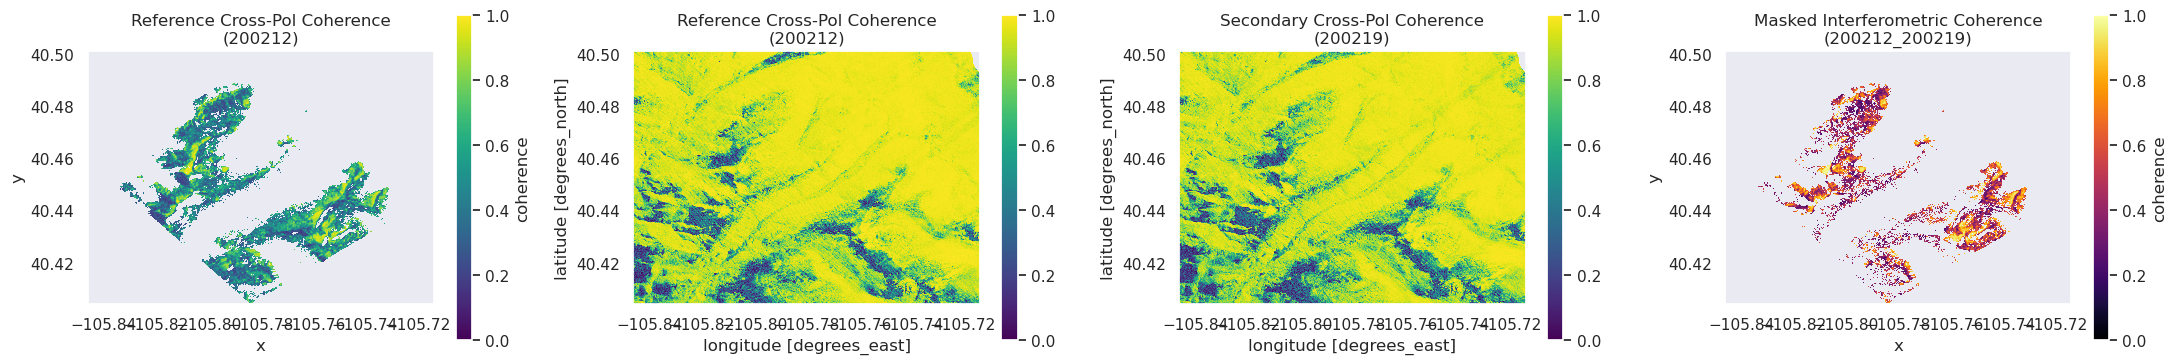

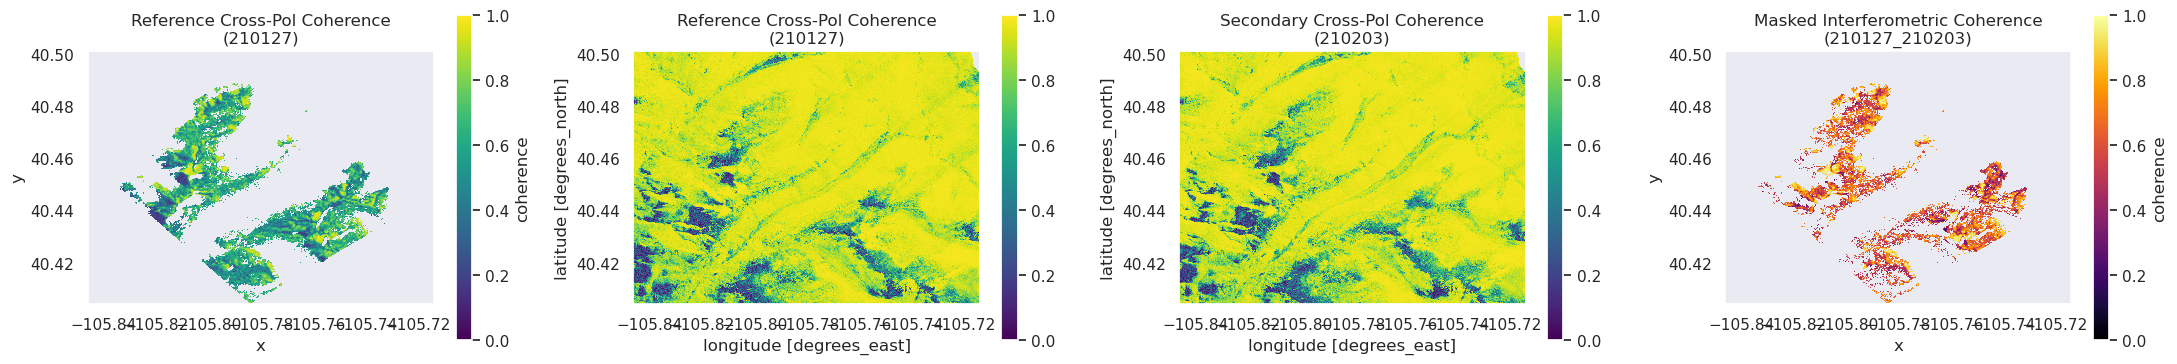

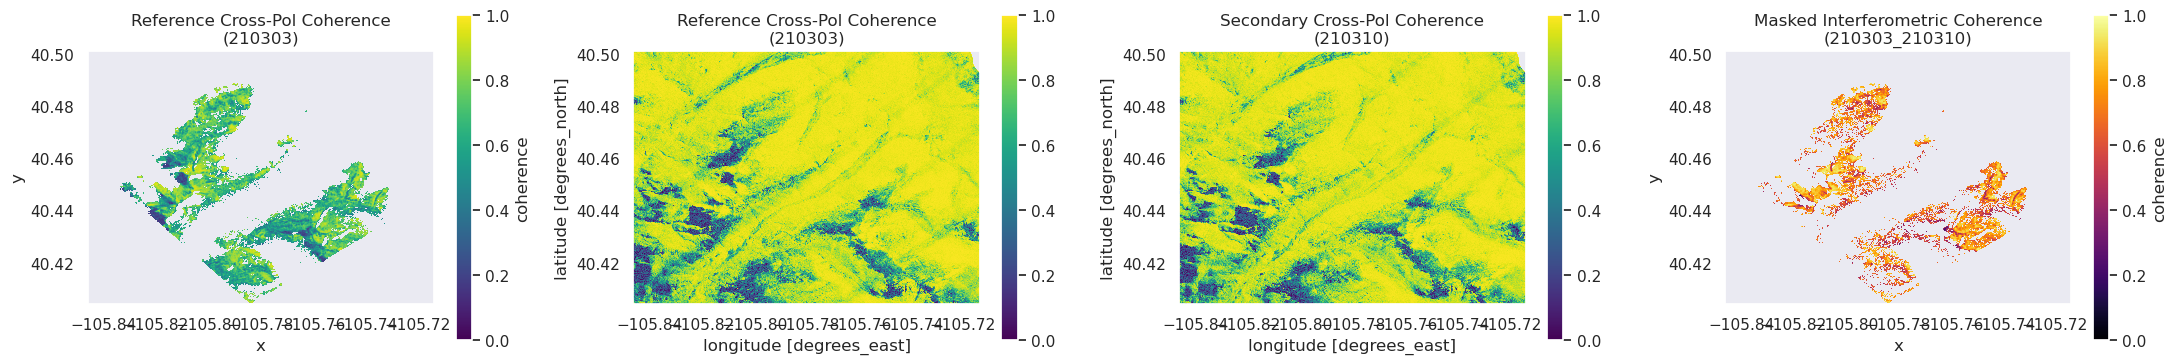

/tmp/ipykernel_179814/3653827858.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(filtered_subsets, dim='pair')


In [46]:
coh_dir: Path = Path(f"{data_dir}/uavsar_cohs/rockmt/32109/")
rmnp_filtered = filter_and_plot_pairs(rmnp_good, coh_dir, xpol_cutoff)

Reprojecting cross-pol datacube for 9 unique flights...


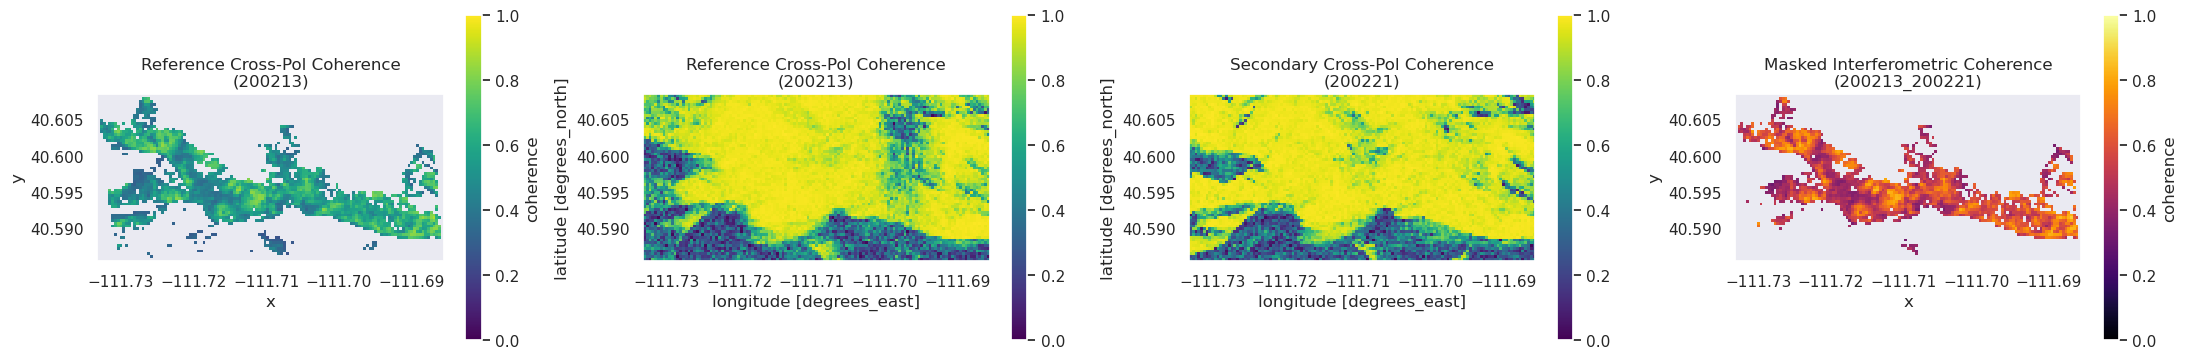

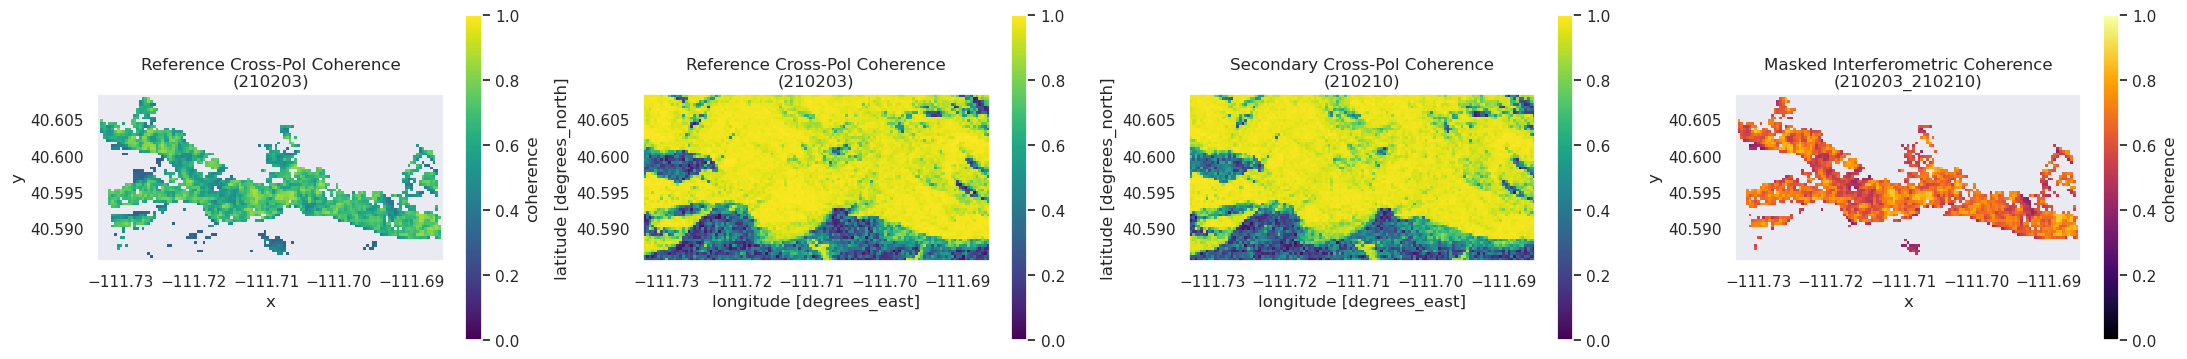

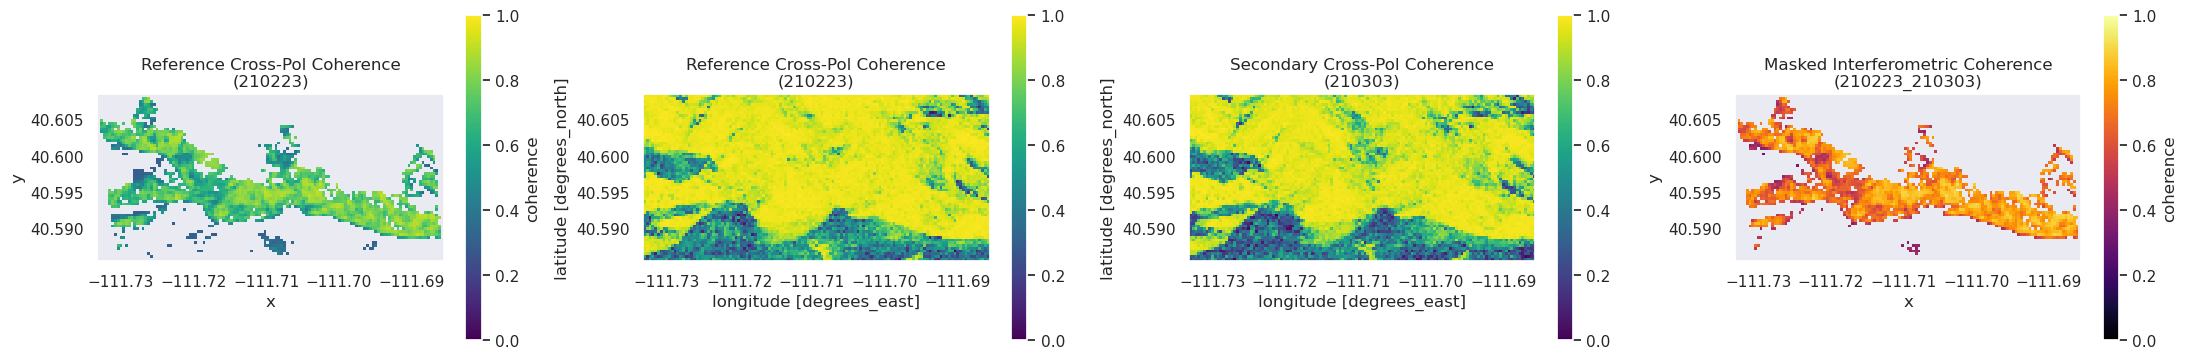

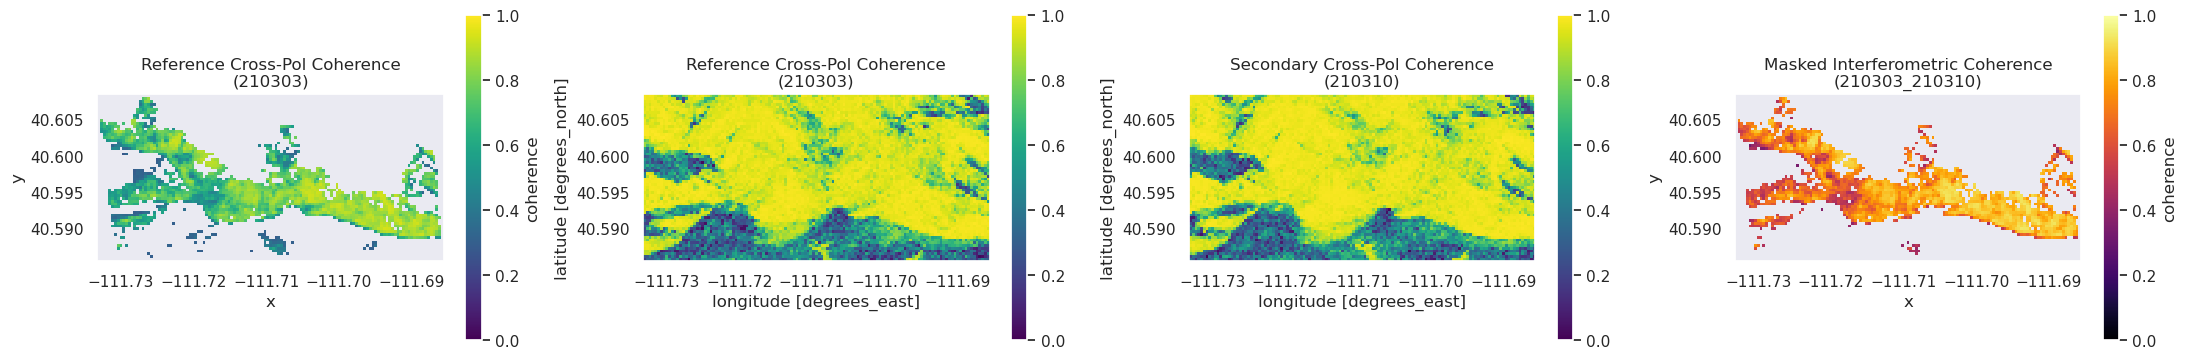

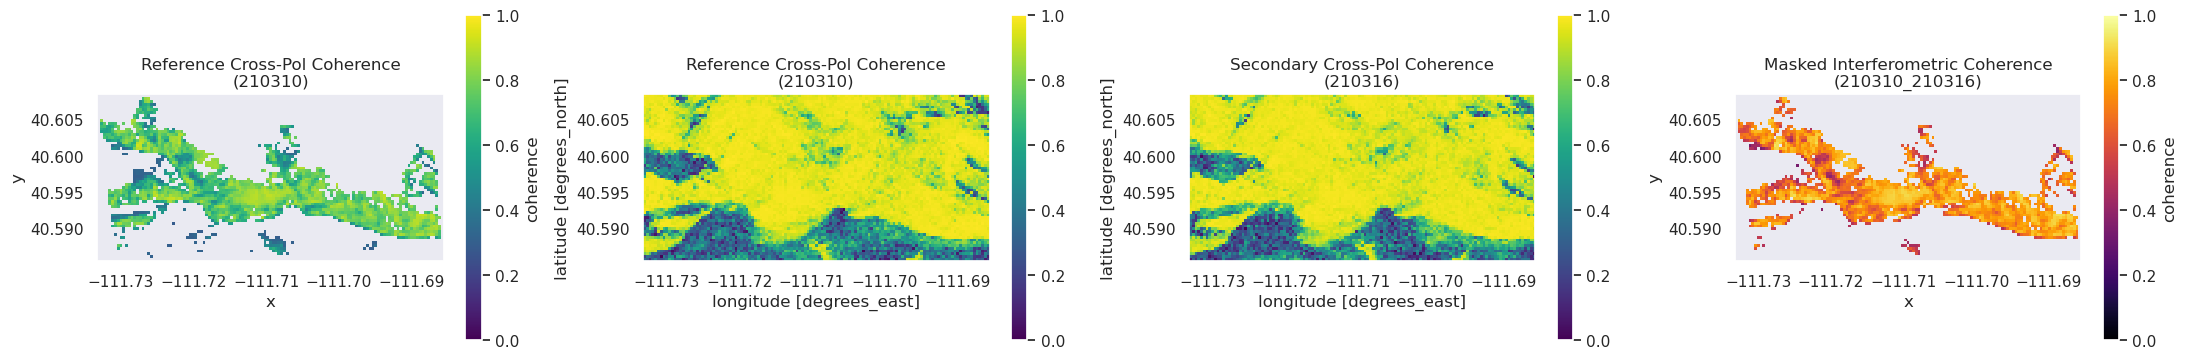

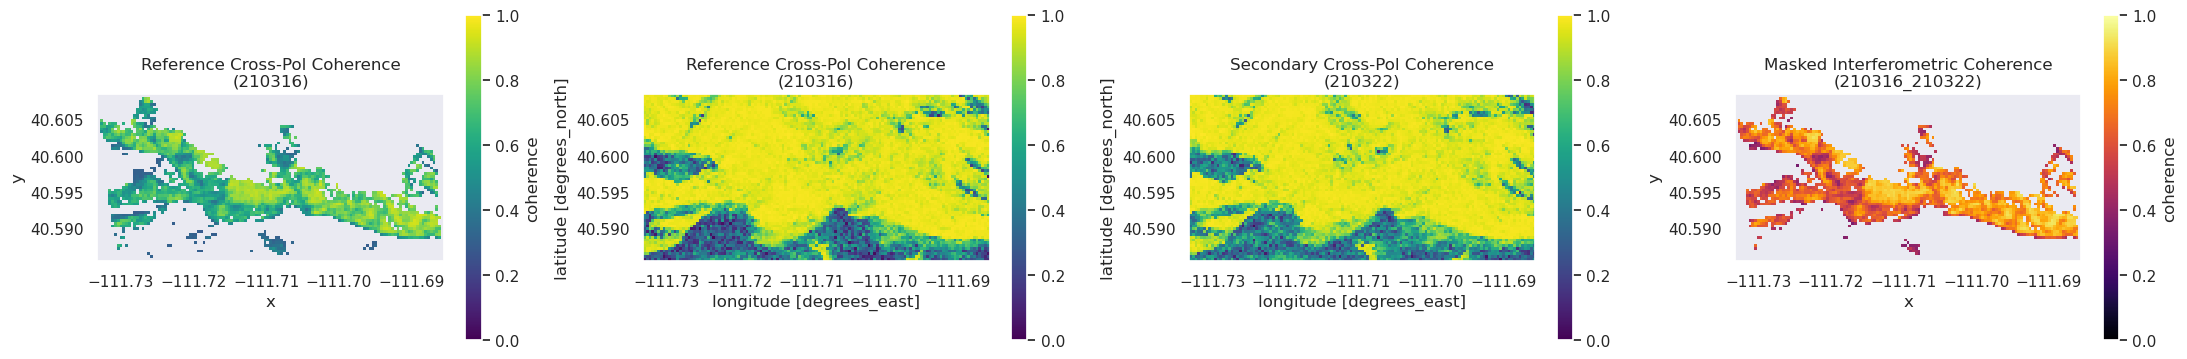

/tmp/ipykernel_179814/3653827858.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(filtered_subsets, dim='pair')


In [47]:
coh_dir: Path = Path(f"{data_dir}/uavsar_cohs/stlake/27129/")
slc_filtered = filter_and_plot_pairs(slc_good, coh_dir, xpol_cutoff)

## Download SNOTEL (snow) and MesoWest (wind) data

I have 3 nearby SNOTEL sites for each location. 

Utah: Snowbird, Brighton, and Thaynes 
Colorado: Cameron Pass, Willow Park, Lake Irene 

In [11]:
snotels = esd.automatic_weather_stations.StationCollection()
print(snotels.all_stations[snotels.all_stations['state'] == 'Utah'])


                          name network  elevation_m  latitude  longitude  \
code                                                                       
907_UT_SNTL        Agua Canyon  SNOTEL      2712.72     37.52    -112.27   
992_UT_SNTL      Bear River RS  SNOTEL      2675.23     40.89    -110.83   
329_UT_SNTL        Beaver Dams  SNOTEL      2435.35     39.14    -111.56   
330_UT_SNTL      Beaver Divide  SNOTEL      2523.74     40.61    -111.10   
332_UT_SNTL    Ben Lomond Peak  SNOTEL      2343.61     41.38    -111.94   
...                        ...     ...          ...       ...        ...   
853_UT_SNTL       Webster Flat  SNOTEL      2805.07     37.58    -112.90   
864_UT_SNTL     White River #1  SNOTEL      2633.78     39.96    -110.99   
865_UT_SNTL         Widtsoe #3  SNOTEL      2938.27     37.84    -111.88   
1228_UT_SNTL     Wrigley Creek  SNOTEL      2842.87     39.13    -111.36   
1197_UT_SNTL  Yankee Reservoir  SNOTEL      2649.32     37.75    -112.77   

           

In [12]:

snotel_mapping = {
    'Cameron': {'triplet': '551_CO_SNTL', 'name': 'Joe Wright'},
    'Willow': {'triplet': '870_CO_SNTL', 'name': 'Willow Park'},
    'Irene': {'triplet': '565_CO_SNTL', 'name': 'Lake Irene'},
    'Brighton' : {'triplet': '366_UT_SNTL', 'name': 'Brighton'},
    'Snowbird': {'triplet': '766_UT_SNTL', 'name': 'Snowbird'},
    'Thaynes': {'triplet': '814_UT_SNTL', 'name': 'Thaynes'},
}

# Define our target evaluation windows across both winter seasons
date_ranges = [
    {'start': '2019-12-01', 'end': '2020-04-01', 'label': 'Winter_2020'},
    {'start': '2020-12-01', 'end': '2021-04-01', 'label': 'Winter_2021'},
]

# Create a clean dictionary container to store your final timeseries arrays
snotel_timeseries_data = {}
snotel_metadata = {}

for site_id, station in snotel_mapping.items():
    snotel_metadata[site_id] = snotels.all_stations.loc[station['triplet']]

    snotel_timeseries_data[site_id] = {}
    print(f"Fetching full historical table for SNOTEL: {station['name']} ({station['triplet']})...")
    
    # Fetch the entire historical table using your snotels instance method
    sntl = esd.automatic_weather_stations.StationCollection()
    sntl.get_data(station['triplet'])  # This should return a DataFrame with a datetime index
    df_full = sntl.data
    
    # Ensure the index is explicitly formatted as a DatetimeIndex so slicing works perfectly
    df_full.index = pd.to_datetime(df_full.index)
    
    for period in date_ranges:
        # Slice the full dataframe to the specific window bounds
        df_clipped = df_full.loc[period['start']:period['end']]
        
        if not df_clipped.empty:
            snotel_timeseries_data[site_id][period['label']] = df_clipped
            print(f"Successfully clipped {period['label']} data array ({len(df_clipped)} records).")
        else:
            print(f"No records found for {station['name']} after clipping to {period['label']}.")


Fetching full historical table for SNOTEL: Joe Wright (551_CO_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Willow Park (870_CO_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Lake Irene (565_CO_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Brighton (366_UT_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Snowbird (766_UT_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Thaynes (814_UT

In [13]:
print(snotel_timeseries_data)

{'Cameron': {'Winter_2020':             TAVG  TMIN  TMAX  SNWD  WTEQ    PRCPSA
datetime                                          
2019-12-01  -8.1 -13.5  -0.5  0.48  0.10  2.50e-03
2019-12-02  -0.8  -3.0   2.9  0.46  0.10  2.50e-03
2019-12-03  -3.0  -6.1  -1.3  0.46  0.10  0.00e+00
2019-12-04  -1.5  -4.2   1.0  0.43  0.10  0.00e+00
2019-12-05  -2.3  -3.6  -0.4  0.43  0.10  2.03e-02
...          ...   ...   ...   ...   ...       ...
2020-03-28  -8.3 -13.1  -3.4  1.85  0.56  0.00e+00
2020-03-29  -5.2 -11.1   0.7  1.80  0.56  0.00e+00
2020-03-30  -3.2 -11.1   4.1  1.73  0.56  0.00e+00
2020-03-31   1.0  -3.1   6.2  1.73  0.56  0.00e+00
2020-04-01   3.9   0.6   8.4  1.73  0.56  0.00e+00

[123 rows x 6 columns], 'Winter_2021':             TAVG  TMIN  TMAX  SNWD  WTEQ    PRCPSA
datetime                                          
2020-12-01  -9.0 -13.8  -3.8  0.43  0.11  1.27e-02
2020-12-02 -17.4 -25.3  -6.1  0.58  0.13  0.00e+00
2020-12-03 -11.7 -19.6  -0.8  0.56  0.13  0.00e+00
2020-12-04  -6

In [14]:
def read_synoptic_csv(file_path):
    metadata = {}

    # 1. Read the top comment lines to extract metadata
    with open(file_path, "r") as file:
        for line in file:
            # Stop searching if we hit a line that doesn't start with a comment
            if not line.startswith("#"):
                break

            # Check for specific metadata tags in the comment line
            if "STATION:" in line:
                metadata["station_code"] = line.split("STATION:")[-1].strip()
            elif "STATION NAME:" in line:
                metadata["station_name"] = (
                    line.split("STATION NAME:")[-1].strip()
                )
            elif "LATITUDE:" in line:
                metadata["latitude"] = float(line.split("LATITUDE:")[-1])
            elif "LONGITUDE:" in line:
                metadata["longitude"] = float(line.split("LONGITUDE:")[-1])
            elif "ELEVATION" in line:
                # Extracts elevation and converts feet to meters if desired
                elevation_ft = float(line.split(":")[-1])
                metadata["elevation_ft"] = elevation_ft
                metadata["elevation_m"] = round(elevation_ft * 0.3048, 2)
            elif "STATE:" in line:
                metadata["state"] = line.split("STATE:")[-1].strip()
    df_weather = pd.read_csv(file_path, header=[10, 11])

    return metadata, df_weather

# iff_meta, iff_stn = read_synoptic_csv(data_dir + 'stations/mesowest/IFF_cardiff_peak_20260424.csv')
# rey_meta, rey_stn = read_synoptic_csv(data_dir + 'stations/mesowest/REY_reynolds_peak_20260424.csv')
# hdp_meta, hdp_stn = read_synoptic_csv(data_dir + 'stations/mesowest/HDP_hidden_peak_20260424.csv')
# print(iff_meta)

In [48]:
# List of your downloaded CSV files
csv_files = ["IFF_cardiff_peak_20260424.csv", 
             "REY_reynolds_peak_20260424.csv", 
             "HDP_hidden_peak_20260424.csv"]

meso_timeseries_data = {}
meso_metadata = {}

date_ranges = [
    {"start": "2019-12-01", "end": "2020-04-01", "label": "Winter_2020"},
    {"start": "2020-12-01", "end": "2021-04-01", "label": "Winter_2021"},
]

for file_path in csv_files:
    # Safely parse the metadata headers and the dataframe separately
    meta, df_raw = read_synoptic_csv(data_dir + 'stations/mesowest/' + file_path)

    # Store metadata globally using the Station ID as the key (e.g., 'HDP')
    station_id = meta["station_code"]
    meso_metadata[station_id] = meta

    # --- Standard Cleaning Steps from before ---
    df_raw.columns = df_raw.columns.get_level_values(0)
    df_raw["Date_Time"] = pd.to_datetime(
        df_raw["Date_Time"], utc=True
    ).dt.tz_localize(None)
    df_raw = df_raw.dropna(axis=1, how="all")

    # Set index for time slicing
    station_df = df_raw.set_index("Date_Time").sort_index()
    if "Station_ID" in station_df.columns:
        station_df = station_df.drop(columns=["Station_ID"])

    # Slice seasons
    station_seasons = {}
    for period in date_ranges:
        start_date = pd.to_datetime(period["start"])
        end_date = pd.to_datetime(period["end"])

        season_df = station_df.loc[start_date:end_date].copy()

        if not season_df.empty:
            season_df = season_df.dropna(axis=1, how="all")

            # Attach the parsed text metadata straight onto the dataframe attribute
            season_df.attrs["metadata"] = meta
            station_seasons[period["label"]] = season_df

    meso_timeseries_data[station_id] = station_seasons

In [49]:
print(meso_timeseries_data)

{'IFF': {'Winter_2020':                      air_temp_set_1  relative_humidity_set_1  \
Date_Time                                                      
2019-12-01 01:10:00          -14.36                    88.30   
2019-12-01 01:20:00          -14.33                    88.30   
2019-12-01 01:30:00          -14.26                    88.40   
2019-12-01 01:40:00          -14.29                    88.40   
2019-12-01 01:50:00          -14.26                    88.30   
...                             ...                      ...   
2020-03-31 23:20:00            0.85                    55.69   
2020-03-31 23:30:00            0.48                    57.99   
2020-03-31 23:40:00            0.58                    56.16   
2020-03-31 23:50:00            0.58                    53.82   
2020-04-01 00:00:00            0.65                    54.90   

                     wind_speed_set_1  wind_direction_set_1  wind_gust_set_1  \
Date_Time                                                      

In [17]:
all_pairs: List[str] = slc_filtered['pair'].values.tolist()
unique_dates: Set[str] = set()
for pair_name in all_pairs:
    # Utilizing character slicing as determined in our previous session
    unique_dates.add(pair_name[:6])  
    unique_dates.add(pair_name[7:13]) 
print(unique_dates)

{'210210', '210322', '210223', '210303', '210203', '200221', '210310', '210316', '200213'}


In [50]:
utah_snotel_stations = ["Snowbird", "Brighton", "Thaynes"]
colorado_snotel_stations = ["Cameron", "Irene", "Willow"]

# MesoWest / Synoptic stations (Dictionary Keys for Wind data)
utah_meso_stations = ["IFF", "REY", "HDP"]
colorado_meso_stations = [""]

# Global mapping for our plotting loop
state_configs = {
    "Utah": {
        "snotel": utah_snotel_stations, 
        "meso": utah_meso_stations
    },
    # "Colorado": {
    #     "snotel": colorado_snotel_stations,
    #     "meso": colorado_meso_stations,
    # },
}

# Target seasons to plot
seasons = ["Winter_2020", "Winter_2021"]

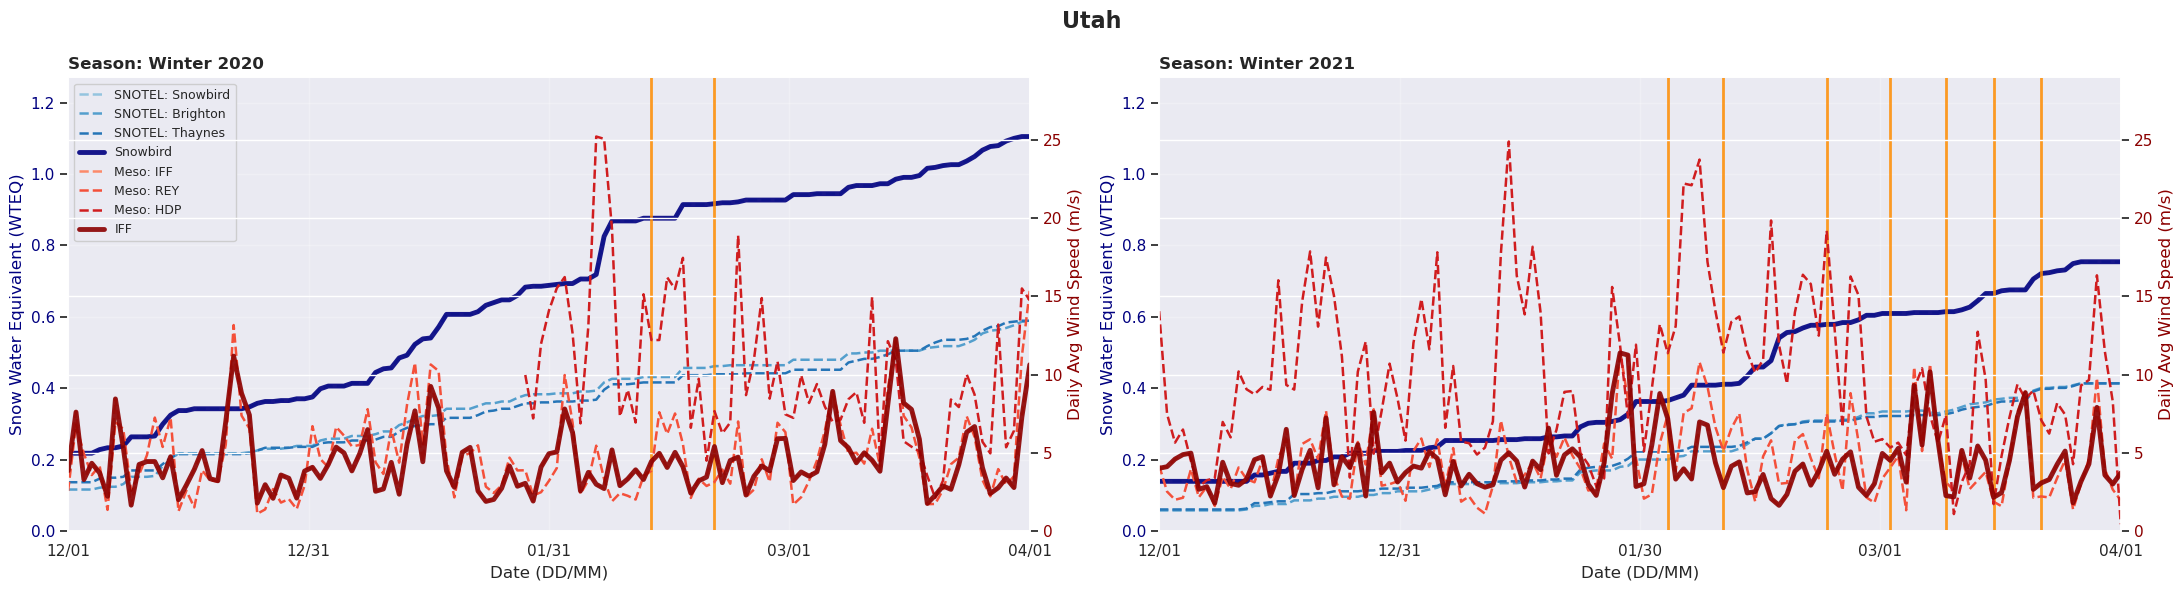

In [51]:
event_dates = pd.to_datetime(list(unique_dates), format="%y%m%d")

# ==============================================================================
# 2. MAIN PLOTTING LOOP
# ==============================================================================
for state_name, config in state_configs.items():

    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=(22, 6), sharex=False, sharey=False
    )
    fig.suptitle(
        f"{state_name}",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    max_swe, max_wind = 0, 0
    right_axes = []

    active_snotel = [s for s in config["snotel"] if s.strip()]
    active_meso = [m for m in config["meso"] if m.strip()]

    for idx, season in enumerate(seasons):
        ax_left = axes[idx]
        ax_right = ax_left.twinx()
        right_axes.append(ax_right)

        ax_left.set_title(
            f"Season: {season.replace('_', ' ')}",
            fontsize=12,
            fontweight="semibold",
            loc="left",
        )

        season_swe_profiles = []
        season_wind_profiles = []

        # --- Plot SNOTEL (Blues) ---
        for num, stn in enumerate(active_snotel):
            if (
                stn in snotel_timeseries_data
                and season in snotel_timeseries_data[stn]
                and not snotel_timeseries_data[stn][season].empty
            ):
                # Pull directly from raw dataset
                swe_series = snotel_timeseries_data[stn][season]["WTEQ"]

                if not swe_series.empty:
                    c_step = (
                        0.4 + (num / len(active_snotel)) * 0.5
                        if len(active_snotel) > 1
                        else 0.7
                    )
                    ax_left.plot(
                        swe_series.index,
                        swe_series.values,
                        color=cm.Blues(c_step),
                        linewidth=1.8,
                        linestyle="--",
                        label=f"SNOTEL: {stn}" if idx == 0 else "",
                    )
                    season_swe_profiles.append(swe_series)
                    max_swe = max(max_swe, swe_series.max())

        # --- Plot MesoWest (Reds) ---
        for num, stn in enumerate(active_meso):
            if (
                stn in meso_timeseries_data
                and season in meso_timeseries_data[stn]
                and not meso_timeseries_data[stn][season].empty
            ):
                # Resample subhourly wind to daily mean directly in line
                wind_series = (
                    meso_timeseries_data[stn][season]["wind_speed_set_1"]
                    .resample("1D")
                    .mean()
                )

                if not wind_series.empty:
                    c_step = (
                        0.4 + (num / len(active_meso)) * 0.5
                        if len(active_meso) > 1
                        else 0.7
                    )
                    ax_right.plot(
                        wind_series.index,
                        wind_series.values,
                        color=cm.Reds(c_step),
                        linewidth=1.8,
                        linestyle="--",
                        label=f"Meso: {stn}" if idx == 0 else "",
                    )
                    season_wind_profiles.append(wind_series)
                    max_wind = max(max_wind, wind_series.max())

        # --- Compute & Plot Aggregated Means ---
        if season_swe_profiles:
            swe_matrix = pd.concat(season_swe_profiles, axis=1)
            mean_swe = swe_matrix.mean(axis=1)
            ax_left.plot(
                snotel_timeseries_data["Snowbird"][season]["WTEQ"].index,
                snotel_timeseries_data["Snowbird"][season]["WTEQ"].values,
                color="navy",
                linewidth=3.5,
                alpha=0.9,
                label="Snowbird" if idx == 0 else "",
            )

        if season_wind_profiles:
            wind_series = (
                    meso_timeseries_data["IFF"][season]["wind_speed_set_1"]
                    .resample("1D")
                    .mean()
                )
            wind_matrix = pd.concat(season_wind_profiles, axis=1)
            mean_wind = wind_matrix.mean(axis=1)
            ax_right.plot(
                wind_series.index,
                wind_series.values,
                color="darkred",
                linewidth=3.5,
                alpha=0.9,
                label="IFF" if idx == 0 else "",
            )

        # --- Establish Chronological Crop Window ---
        all_profiles = season_swe_profiles + season_wind_profiles
        if all_profiles:
            current_year = all_profiles[0].index.min().year
            if all_profiles[0].index.min().month < 12:
                current_year = all_profiles[0].index.max().year - 1
        else:
            current_year = 2019 if "2020" in season else 2020

        xmin = pd.Timestamp(year=current_year, month=12, day=1)
        xmax = pd.Timestamp(year=current_year + 1, month=4, day=1)
        ax_left.set_xlim(xmin, xmax)

        # --- Add Vertical Event Storm Lines ---
        for edate in event_dates:
            if xmin <= edate <= xmax:
                ax_left.axvline(
                    x=edate,
                    color="darkorange",
                    linestyle="-",
                    linewidth=2,
                    alpha=0.85,
                    #label="Storm Event" if idx == 0 else "",
                )

        # --- Manual DD/MM Formatting (Zero External Imports) ---
        # Generate 5 clean, evenly spaced calendar ticks across the winter window
        tick_dates = pd.date_range(start=xmin, end=xmax, periods=5)
        ax_left.set_xticks(tick_dates)
        # Reformat datetime objects directly to DD/MM strings
        ax_left.set_xticklabels(tick_dates.strftime("%m/%d"))

        # Visual Formatting
        ax_left.set_ylabel("Snow Water Equivalent (WTEQ)", color="navy")
        ax_left.tick_params(axis="y", labelcolor="navy")
        ax_right.set_ylabel("Daily Avg Wind Speed (m/s)", color="darkred")
        ax_right.tick_params(axis="y", labelcolor="darkred")

        ax_left.grid(True, alpha=0.25)
        ax_left.set_xlabel("Date (DD/MM)")

        if idx == 0:
            lines_l, labels_l = ax_left.get_legend_handles_labels()
            lines_r, labels_r = ax_right.get_legend_handles_labels()
            ax_left.legend(
                lines_l + lines_r,
                labels_l + labels_r,
                loc="upper left",
                framealpha=0.95,
                fontsize=9,
            )

    # Enforce global scales symmetrically across both subplots
    for ax_l, ax_r in zip(axes, right_axes):
        ax_l.set_ylim(0, max_swe * 1.15 if max_swe > 0 else 10)
        ax_r.set_ylim(0, max_wind * 1.15 if max_wind > 0 else 30)

    plt.tight_layout()
    plt.show()

In [52]:
slc_filtered = slc_filtered[["coherence", "elevation"]]
slc_filtered

<xarray.Dataset> Size: 362kB
Dimensions:      (flight_id: 1, pair: 6, y: 60, x: 125)
Coordinates:
  * flight_id    (flight_id) <U5 20B '27129'
  * pair         (pair) <U13 312B '200213_200221' ... '210316_210322'
  * y            (y) float64 480B 40.61 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * x            (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7 -111.7
    band         int64 8B ...
    spatial_ref  int64 8B 0
    quantile     float64 8B 0.4
Data variables:
    coherence    (flight_id, pair, y, x) float32 180kB dask.array<chunksize=(1, 1, 30, 125), meta=np.ndarray>
    elevation    (pair, y, x, flight_id) float32 180kB dask.array<chunksize=(1, 60, 125, 1), meta=np.ndarray>

In [53]:
ds_final = slc_filtered

# Parse the start and end calendar dates for each baseline pair track
pair_bounds = {}
for pair_name in ds_final.pair.values:
    start_str, end_str = pair_name.split("_")
    start_dt = pd.to_datetime(start_str, format="%y%m%d")
    end_dt = pd.to_datetime(end_str, format="%y%m%d")
    pair_bounds[pair_name] = (start_dt, end_dt)

# Create a continuous, global 1D daily timeline covering the entire span
all_starts = [bounds[0] for bounds in pair_bounds.values()]
all_ends = [bounds[1] for bounds in pair_bounds.values()]
global_time_index = pd.date_range(
    start=min(all_starts), end=max(all_ends), freq="D"
)

# Combine and unique your master station inventory list (skipping dummy values)
all_stations = list(
    set(
        utah_snotel_stations
        # + colorado_snotel_stations
        + utah_meso_stations
        # + colorado_meso_stations
    )
)
active_stations = sorted([s for s in all_stations if s.strip()])


# ==============================================================================
# 2. CONSOLIDATE AND STRUCTURIZE GROUND STATION DATA
# ==============================================================================
# Build empty pandas dataframes to handle timeline normalization automatically
swe_master_df = pd.DataFrame(
    np.nan, index=global_time_index, columns=active_stations
)
wind_master_df = pd.DataFrame(
    np.nan, index=global_time_index, columns=active_stations
)
wind_u_master_df = pd.DataFrame(
    np.nan, index=global_time_index, columns=active_stations
)
wind_v_master_df = pd.DataFrame(
    np.nan, index=global_time_index, columns=active_stations
)

for stn in active_stations:
    # --- Compile Continuous SNOTEL Datasets ---
    if stn in snotel_timeseries_data:
        snotel_segments = []
        for season in snotel_timeseries_data[stn]:
            if "WTEQ" in snotel_timeseries_data[stn][season].columns:
                snotel_segments.append(snotel_timeseries_data[stn][season]["WTEQ"])
        if snotel_segments:
            # Flatten, drop duplicates across calendar boundaries, and index map
            combined_swe = pd.concat(snotel_segments)
            combined_swe = combined_swe[~combined_swe.index.duplicated(keep="first")]
            swe_master_df[stn] = combined_swe.reindex(global_time_index)

    # --- Compile Continuous MesoWest Datasets ---
    if stn in meso_timeseries_data:
        meso_segments = []
        for season in meso_timeseries_data[stn]:
            if "wind_speed_set_1" in meso_timeseries_data[stn][season].columns:
                # Force aggregate subhourly profiles into daily clean averages
                daily_mean_wind = (
                    meso_timeseries_data[stn][season]["wind_speed_set_1"]
                    .resample("1D")
                    .mean()
                )
                meso_segments.append(daily_mean_wind)
        if meso_segments:
            combined_wind = pd.concat(meso_segments)
            combined_wind = combined_wind[~combined_wind.index.duplicated(keep="first")]
            wind_master_df[stn] = combined_wind.reindex(global_time_index)
    # Inside your station loop, replace your MesoWest compilation section with this:
    if stn in meso_timeseries_data:
        u_segments = []
        v_segments = []
        for season in meso_timeseries_data[stn]:
            df_season = meso_timeseries_data[stn][season]
            if "wind_speed_set_1" in df_season.columns and "wind_direction_set_1" in df_season.columns:
                speed = df_season["wind_speed_set_1"]
                wd_rad = np.deg2rad(df_season["wind_direction_set_1"])
                
                # Decompose to mathematical vectors (weighted by speed)
                # Note: Meteorological wind direction is the direction the wind blows FROM
                u_subhourly = speed * np.sin(wd_rad)
                v_subhourly = speed * np.cos(wd_rad)
                
                # Now it is safe to resample daily
                u_segments.append(u_subhourly.resample("1D").mean())
                v_segments.append(v_subhourly.resample("1D").mean())
                
        if u_segments:
            combined_u = pd.concat(u_segments)
            combined_u = combined_u[~combined_u.index.duplicated(keep="first")]
            wind_u_master_df[stn] = combined_u.reindex(global_time_index)
            
            combined_v = pd.concat(v_segments)
            combined_v = combined_v[~combined_v.index.duplicated(keep="first")]
            wind_v_master_df[stn] = combined_v.reindex(global_time_index)


# ==============================================================================
# 3. BUILD THE RADAR PAIR TEMPORAL BOUNDARY MASK
# ==============================================================================
# Row dimension corresponds to baseline pair tracks, columns correspond to the timeline days
mask_array = np.zeros(
    (len(ds_final.pair), len(global_time_index)), dtype=bool
)

for idx, pair_name in enumerate(ds_final.pair.values):
    start_dt, end_dt = pair_bounds[pair_name]
    # Set matrix positions to True only if calendar days overlap flight intervals
    mask_array[idx, :] = (global_time_index >= start_dt) & (
        global_time_index <= end_dt
    )


# ==============================================================================
# 4. ENCODE NEW ARRAYS INTO XARRAY OBJECT
# ==============================================================================
# Wrap matrices with appropriate dimension headings and tracking coordinates
da_swe = xr.DataArray(
    swe_master_df.values,
    coords=[global_time_index, active_stations],
    dims=["time", "station"],
)
da_wind = xr.DataArray(
    wind_master_df.values,
    coords=[global_time_index, active_stations],
    dims=["time", "station"],
)
da_u_wind = xr.DataArray(
    wind_u_master_df.values,
    coords=[global_time_index, active_stations],
    dims=["time", "station"],
)
da_v_wind = xr.DataArray(
    wind_v_master_df.values,
    coords=[global_time_index, active_stations],
    dims=["time", "station"],
)
da_mask = xr.DataArray(
    mask_array, coords=[ds_final.pair.values, global_time_index], dims=["pair", "time"]
)

# Merge back into your main spatial structure
ds_final = ds_final.assign(
    # station_swe=da_swe, station_wind=da_wind, in_pair_window=da_mask
    station_swe=da_swe, station_wind_u=da_u_wind, station_wind_v=da_v_wind, station_wind=da_wind, in_pair_window=da_mask
)

ds_final

<xarray.Dataset> Size: 445kB
Dimensions:         (flight_id: 1, pair: 6, y: 60, x: 125, time: 404, station: 6)
Coordinates:
  * flight_id       (flight_id) <U5 20B '27129'
  * pair            (pair) <U13 312B '200213_200221' ... '210316_210322'
  * y               (y) float64 480B 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * x               (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7
  * time            (time) datetime64[us] 3kB 2020-02-13 ... 2021-03-22
  * station         (station) <U8 192B 'Brighton' 'HDP' ... 'Snowbird' 'Thaynes'
    band            int64 8B ...
    spatial_ref     int64 8B 0
    quantile        float64 8B 0.4
Data variables:
    coherence       (flight_id, pair, y, x) float32 180kB dask.array<chunksize=(1, 1, 30, 125), meta=np.ndarray>
    elevation       (pair, y, x, flight_id) float32 180kB dask.array<chunksize=(1, 60, 125, 1), meta=np.ndarray>
    station_swe     (time, station) float64 19kB 0.4318 nan ... 0.7214 0.3988
    station_wind_u  (time, station) float64 19kB nan -11.32 -3.254 ... nan nan
    station_wind_v  (time, station) float64 19kB nan 4.505 2.484 ... nan nan
    station_wind    (time, station) float64 19kB nan 12.22 4.456 ... nan nan
    in_pair_window  (pair, time) bool 2kB True True True True ... True True True

In [22]:
ds_final = ds_final.sel(station=['IFF', 'Snowbird'])

In [54]:
# X-AXIS: Mask SWE by pair window, then average over time and across all stations
pair_swe = (
    ds_final["station_swe"].diff(dim='time')
    .where(ds_final["in_pair_window"])
    .sum(dim=["time", "station"])
    # .mean(dim=["time", "station"])
)

# COLORBAR (C): Mask Wind by pair window, then average over time and stations
pair_wind = (
    ds_final["station_wind"]
    .where(ds_final["in_pair_window"])
    .mean(dim=["time", "station"])
)

# Create a dictionary to hold the final resolved wind angle for each pair
pair_wind_angles_rad = {}

for pair_name in ds_final.pair.values:
    # Isolate the time window for the pair
    time_mask = ds_final["in_pair_window"].sel(pair=pair_name)
    
    # Calculate the average u and v vectors across the pair window and all stations
    mean_u = float(ds_final["station_wind_u"].where(time_mask).mean(dim=["time", "station"]).values)
    mean_v = float(ds_final["station_wind_v"].where(time_mask).mean(dim=["time", "station"]).values)
    
    # Calculate the weighted mean direction angle in radians
    # np.arctan2(u, v) maps beautifully to standard meteorological angles
    avg_dir_rad = np.arctan2(mean_u, mean_v)
    
    # Standardize negative angles to a clean 0 to 2pi circle
    if avg_dir_rad < 0:
        avg_dir_rad += 2 * np.pi
        
    pair_wind_angles_rad[pair_name] = avg_dir_rad

# Y-AXIS: Average scene coherence across all pixels (y, x) and flight tracks
# (coherence original dimensions: flight_id, pair, y, x)
pair_coherence = ds_final["coherence"].mean(dim=["y", "x", "flight_id"])

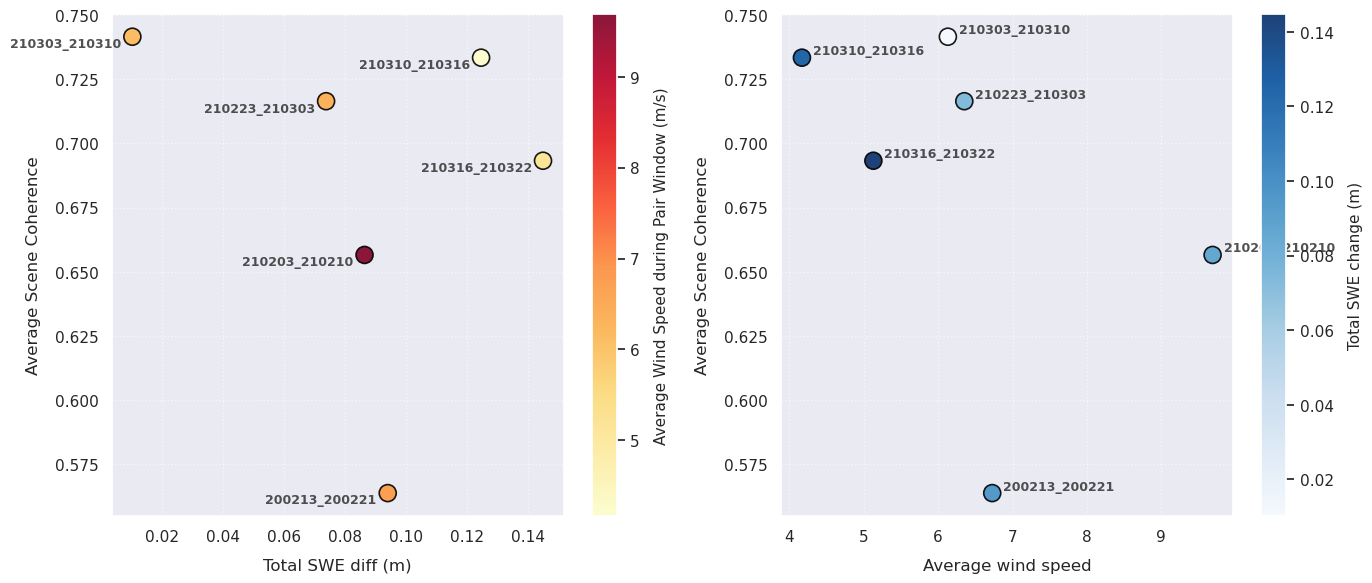

In [55]:
# ==============================================================================
# 2. GENERATE THE SCATTER PLOT
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create the scatter plot
scatter = axes[0].scatter(
    pair_swe.values,
    pair_coherence.values,
    c=pair_wind.values,
    cmap="YlOrRd",  # Yellow to Orange to Red gradient for wind speed
    s=150,  # Maker size
    edgecolors="black",  # Crisp border for visibility
    linewidths=1.2,
    alpha=0.9,
)

# Annotate each point with its specific pair label (e.g., '200213_200221')
for i, pair_label in enumerate(ds_final.pair.values):
    axes[0].annotate(
        pair_label,
        (pair_swe.values[i], pair_coherence.values[i]),
        textcoords="offset points",
        xytext=(-8, -5),
        ha="right",
        va="center",
        fontsize=9,
        fontweight="semibold",
        alpha=0.8,
        zorder=5,
    )

# Formatting axes and labels
axes[0].set_xlabel("Total SWE diff (m)", fontsize=12, labelpad=10)
axes[0].set_ylabel("Average Scene Coherence", fontsize=12, labelpad=10)
# axes[0].title(
#     "",
#     fontsize=14,
#     fontweight="bold",
#     pad=15,
# )

# Add grid lines beneath the scatter markers
axes[0].grid(True, linestyle=":", alpha=0.6, zorder=0)
# axes[0].gca().set_axisbelow(True)

# Add and label the colorbar for wind speed
cbar = plt.colorbar(scatter)
cbar.set_label("Average Wind Speed during Pair Window (m/s)", fontsize=11, labelpad=10)

scatter = axes[1].scatter(
    pair_wind.values,
    pair_coherence.values,
    c=pair_swe.values,
    cmap="Blues",  # Blues for SWE
    s=150,  # Maker size
    edgecolors="black",  # Crisp border for visibility
    linewidths=1.2,
    alpha=0.9,
)

# Annotate each point with its specific pair label (e.g., '200213_200221')
for i, pair_label in enumerate(ds_final.pair.values):
    axes[1].annotate(
        pair_label,
        (pair_wind.values[i], pair_coherence.values[i]),
        textcoords="offset points",
        xytext=(8, 5),
        ha="left",
        va="center",
        fontsize=9,
        fontweight="semibold",
        alpha=0.8,
        zorder=5,
    )

# Formatting axes and labels
axes[1].set_xlabel("Average wind speed", fontsize=12, labelpad=10)
axes[1].set_ylabel("Average Scene Coherence", fontsize=12, labelpad=10)
# axes[0].title(
#     "",
#     fontsize=14,
#     fontweight="bold",
#     pad=15,
# )

# Add grid lines beneath the scatter markers
axes[1].grid(True, linestyle=":", alpha=0.6, zorder=0)
# axes[0].gca().set_axisbelow(True)

# Add and label the colorbar for wind speed
cbar = plt.colorbar(scatter)
cbar.set_label("Total SWE change (m)", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

Top 6 Pairs selected for plotting: ['210316_210322', '210310_210316', '210203_210210', '210223_210303']


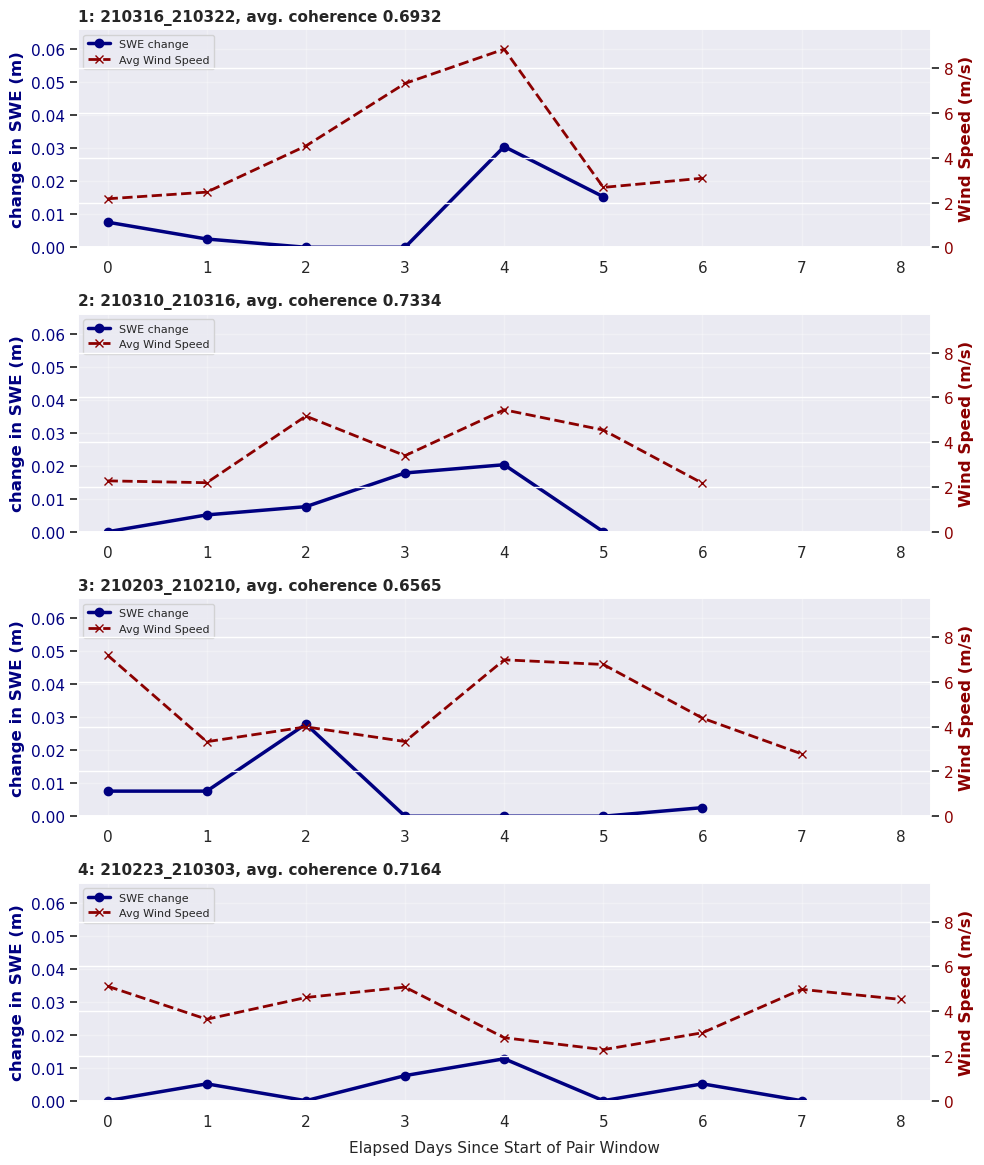

In [56]:
top_3_pairs = (
    pair_swe.to_series().sort_values(ascending=False).head(5).index.tolist()
)
top_3_pairs = ['210316_210322', '210310_210316', '210203_210210', '210223_210303']
print(f"Top 6 Pairs selected for plotting: {top_3_pairs}")

# ==============================================================================
# 2. GENERATE VERTICALLY STACKED TIME SERIES SUBPLOTS
# ==============================================================================
# Create 3 subplots stacked vertically, sharing the left Y-axis scale if desired
fig, axes = plt.subplots(
    nrows=len(top_3_pairs), ncols=1, figsize=(10, len(top_3_pairs)*3), sharex=False, sharey=False
)
fig.suptitle(
    "",
    fontsize=14,
    fontweight="bold",
    y=0.97,
)

# Determine global max bounds across just these 3 pairs to enforce uniform Y-axis scales
swe_max_val = 0
wind_max_val = 0

for pair_name in top_3_pairs:
    time_mask = ds_final["in_pair_window"].sel(pair=pair_name)

    # Apply the mask directly to the specific 1D/2D weather variables (ignoring grid coordinates)
    swe_slice = ds_final["station_swe"].sel(station="Snowbird").where(time_mask, drop=True)
    wind_slice = ds_final["station_wind"].sel(station="IFF").where(time_mask, drop=True)

    # Collect maxes safely
    if swe_slice.size > 0:
        swe_max_val = max(swe_max_val, float(swe_slice.max().values))
        swe_max_val = 0.06
    if wind_slice.size > 0:
        wind_max_val = max(wind_max_val, float(wind_slice.max().values))

# Loop through and populate each subplot axis
for idx, pair_name in enumerate(top_3_pairs):
    ax_left = axes[idx]
    ax_right = ax_left.twinx()

    # Isolate the continuous time records falling strictly inside this pair's flight window
    time_mask = ds_final["in_pair_window"].sel(pair=pair_name)
    
    # Extract data slices directly using the isolated time mask
    swe_series = ds_final["station_swe"].sel(station="Snowbird").where(time_mask, drop=True).diff(dim='time').to_series().dropna()
    wind_series = ds_final["station_wind"].sel(station="IFF").where(time_mask, drop=True).to_series().dropna()

    swe_relative_days = (swe_series.index - swe_series.index.min()).days
    wind_relative_days = (wind_series.index - wind_series.index.min()).days

    # --- Plot Snowbird SWE (Left Axis - Blue) ---
    ax_left.plot(
        swe_relative_days,
        swe_series.values,
        color="navy",
        linewidth=2.5,
        marker="o",
        label="SWE change",
    )

    # --- Plot IFF Wind Speed (Right Axis - Red) ---
    ax_right.plot(
        wind_relative_days,
        wind_series.values,
        color="darkred",
        linewidth=2.0,
        linestyle="--",
        marker="x",
        label="Avg Wind Speed",
    )

    # Subplot Titles & Metadata labeling
    ax_left.set_title(
        f"{idx+1}: {pair_name}, avg. coherence {ds_final['coherence'].sel(pair=pair_name).mean().values:.4f}",
        fontsize=11,
        fontweight="semibold",
        loc="left",
    )

    # Uniform Layout & Axis Scaling Parameters
    ax_left.set_ylabel("change in SWE (m)", color="navy", fontweight="semibold")
    ax_left.tick_params(axis="y", labelcolor="navy")
    ax_left.set_ylim(0, swe_max_val * 1.1)

    ax_right.set_ylabel("Wind Speed (m/s)", color="darkred", fontweight="semibold")
    ax_right.tick_params(axis="y", labelcolor="darkred")
    ax_right.set_ylim(0, wind_max_val * 1.1)

    # FORCE EXACT SAME X-AXIS SPACE SCALE PER DAY:
    # Setting limits from 0 to 8 means 1 day takes up the exact same width on all three plots,
    # even if an 8-day interval fills the window completely and a 7-day interval stops short.
    ax_left.set_xlim(-0.3, 8.3)
    ax_left.set_xticks(range(9))

    ax_left.grid(True, alpha=0.3)

    # Consolidate Legends elegantly inside the frames
    lines_l, labels_l = ax_left.get_legend_handles_labels()
    lines_r, labels_r = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_l + lines_r, labels_l + labels_r, loc="upper left", fontsize=8)

# Add X-axis label only to the bottom-most plot to avoid repetitive clutter
axes[-1].set_xlabel("Elapsed Days Since Start of Pair Window", fontsize=11, labelpad=8)

plt.tight_layout()
plt.show()

In [26]:
ds_final

<xarray.Dataset> Size: 393kB
Dimensions:         (flight_id: 1, pair: 6, y: 60, x: 125, time: 404, station: 2)
Coordinates:
  * flight_id       (flight_id) <U5 20B '27129'
  * pair            (pair) <U13 312B '200213_200221' ... '210316_210322'
  * y               (y) float64 480B 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * x               (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7
  * time            (time) datetime64[us] 3kB 2020-02-13 ... 2021-03-22
  * station         (station) <U8 64B 'IFF' 'Snowbird'
    band            int64 8B ...
    spatial_ref     int64 8B 0
    quantile        float64 8B 0.4
Data variables:
    coherence       (flight_id, pair, y, x) float32 180kB dask.array<chunksize=(1, 1, 30, 125), meta=np.ndarray>
    elevation       (pair, y, x, flight_id) float32 180kB dask.array<chunksize=(1, 60, 125, 1), meta=np.ndarray>
    station_swe     (time, station) float64 6kB nan 0.8763 nan ... nan 0.7214
    station_wind_u  (time, station) float64 6kB -3.254 nan -3.731 ... -1.069 nan
    station_wind_v  (time, station) float64 6kB 2.484 nan -2.584 ... 2.174 nan
    station_wind    (time, station) float64 6kB 4.456 nan 4.982 ... 3.086 nan
    in_pair_window  (pair, time) bool 2kB True True True True ... True True True

In [57]:

# ==============================================================================
# 1. USER CONFIGURATION
# ==============================================================================
# Control the number of directional bins (e.g., 4, 8, 16)
num_divisions = 16

# ==============================================================================
# 2. COMPUTE ASPECT AND INITIAL CLEANUP
# ==============================================================================
# Collapse spatial elevation to a 2D grid (xrspatial requirement)
dem_2d = ds_final["elevation"].mean(dim=["pair", "flight_id"])

# Compute aspect: output values range from 0° to 360° (Flat areas = -1.0)
terrain_aspect = aspect(dem_2d)

# Mean coherence over flight_id tracks, preserving individual 'pair' timelines
# Output dimensions: (pair, y, x)
pair_coherence_maps = ds_final["coherence"].mean(dim="flight_id")

# ==============================================================================
# 3. MULTI-DIMENSIONAL BINNING ENGINE (PRESERVES FLIGHT PAIRS)
# ==============================================================================
bin_width = 360.0 / num_divisions
bin_edges = np.arange(0, 360 + bin_width, bin_width) - (bin_width / 2.0)

# Track the midpoint angle of each wedge (0° = North, 90° = East)
compass_angles_deg = np.arange(0, 360, bin_width)

# Dictionary to collect 1D arrays per pair
pair_vectors = {}

for pair_name in ds_final.pair.values:
    # Isolate the 2D coherence raster for this specific flight period
    single_pair_coherence = pair_coherence_maps.sel(pair=pair_name)
    sector_means = []

    for i in range(num_divisions):
        low_bound = bin_edges[i]
        high_bound = bin_edges[i + 1]

        # Handle North wraparound conditions crossing 360°/0° boundary
        if low_bound < 0:
            mask = (terrain_aspect >= (360 + low_bound)) | (
                terrain_aspect < high_bound
            )
        elif high_bound > 360:
            mask = (terrain_aspect >= low_bound) | (
                terrain_aspect < (high_bound - 360)
            )
        else:
            mask = (terrain_aspect >= low_bound) & (terrain_aspect < high_bound)

        # Drop flat ground noise values
        mask = mask & (terrain_aspect >= 0)

        # Calculate average value inside this specific terrain aspect subset
        coherence_subset = single_pair_coherence.where(mask)

        if coherence_subset.notnull().any():
            mean_val = float(coherence_subset.mean().values)
        else:
            mean_val = 0.0

        sector_means.append(mean_val)

    pair_vectors[pair_name] = sector_means

# Build a pristine multi-dimensional DataArray structure
da_directional_coherence = xr.DataArray(
    data=[pair_vectors[p] for p in ds_final.pair.values],
    coords=[ds_final.pair.values, compass_angles_deg],
    dims=["pair", "angle"],
)

print("--- Step 1 Complete ---")
print("New multi-dimensional data structure created:")
print(da_directional_coherence)

--- Step 1 Complete ---
New multi-dimensional data structure created:
<xarray.DataArray (pair: 6, angle: 16)> Size: 768B
array([[0.64260215, 0.61418021, 0.53245282, 0.45639658, 0.40593407,
        0.42573684, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.53181279, 0.53300601, 0.52821696,
        0.60380203],
       [0.68926895, 0.66657883, 0.63222075, 0.61485779, 0.60718971,
        0.59790754, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.60340595, 0.64027733, 0.7101202 ,
        0.71234274],
       [0.77517104, 0.76229781, 0.71652293, 0.65545112, 0.62959445,
        0.6580255 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.63314831, 0.71434557, 0.75437623,
        0.76394355],
       [0.79557097, 0.79512388, 0.75214297, 0.65504825, 0.56269848,
        0.6099602 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.71401983, 0.71166581, 0.75557792,


Pair 210316_210322 Wind Direction: 229.0°
Pair 210310_210316 Wind Direction: 329.0°
Pair 210203_210210 Wind Direction: 266.7°
Pair 210223_210303 Wind Direction: 266.9°


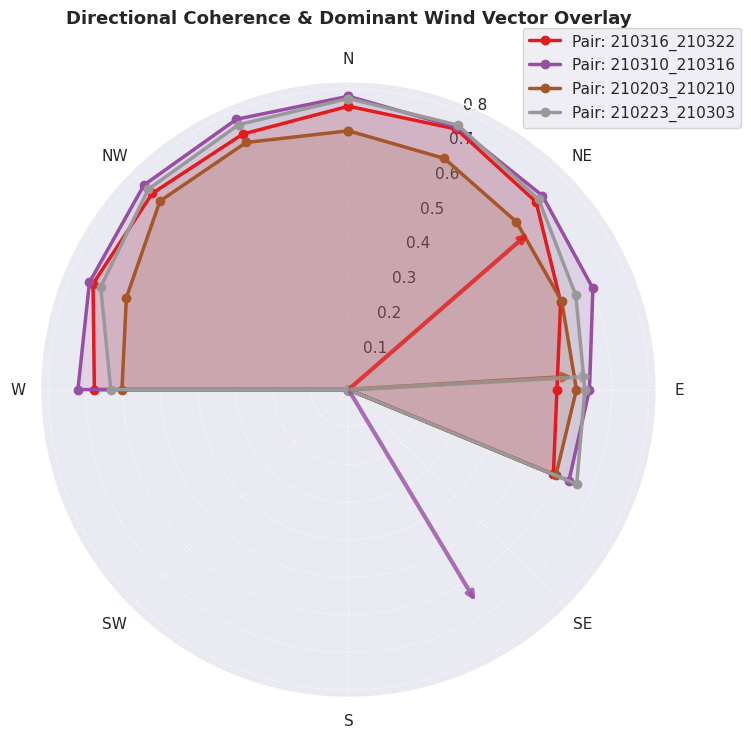

In [58]:
# ==============================================================================
# 1. VISUALIZATION FILTER CONFIGURATION
# ==============================================================================
# Uses top_3_pairs as configured above
pairs_to_plot = top_3_pairs

# ==============================================================================
# 2. POLAR MULTI-LINE OVERLAY PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

# Grab the colormap object cleanly from matplotlib
cmap = plt.get_cmap("Set1")

# Extract evenly spaced colors based on how many pairs you want to plot
line_colors = cmap(np.linspace(0, 1, len(pairs_to_plot)))

# Pull the source angular values out of the coordinate data array
raw_angles_deg = da_directional_coherence.angle.values
angles_rad = np.deg2rad(raw_angles_deg)

# To wrap lines completely around the circle, append the 360-degree point
angles_loop_rad = np.append(angles_rad, angles_rad[0])

for idx, pair_name in enumerate(pairs_to_plot):
    if pair_name not in da_directional_coherence.pair.values:
        print(f"Skipping key '{pair_name}': Variable name not present in dataset.")
        continue

    # --- FIX 1: DEFINE COLOR FIRST ---
    # Moved color assignment to the top of the loop so it's defined before use
    plot_color = line_colors[idx]

    # Pull the directional signature values for this specific winter track
    coherence_values = da_directional_coherence.sel(pair=pair_name).values
    values_loop = np.append(coherence_values, coherence_values[0])
    
    # Extract and log wind direction values
    wind_angle = pair_wind_angles_rad[pair_name]
    print(f"Pair {pair_name} Wind Direction: {np.rad2deg(wind_angle):.1f}°")
    
    # Draw an arrow pointing outward in the direction the wind is blowing TOWARD
    # (Flip the vector by 180 degrees/pi radians if you want to show where wind is going)
    arrow_direction = (wind_angle + np.pi) % (2 * np.pi)
    
    # --- FIX 2: DYNAMIC ARROW SCALING ---
    # Instead of hardcoding 0.4, scale the arrow tip length dynamically to 
    # match the visual scale of this specific pair's coherence magnitude
    arrow_max_radius = float(np.max(coherence_values)) * 0.85
    
    # Place a clean arrow vector indicating the wind direction
    ax.annotate(
        "",
        xy=(arrow_direction, arrow_max_radius),  # Arrow tip (Angle, Radius)
        xytext=(arrow_direction, 0.0),           # Arrow base at the center of the plot
        arrowprops=dict(
            arrowstyle="->", 
            color=plot_color, 
            lw=3, 
            alpha=0.8
        ),
        zorder=6
    )

    # Plot the radar line and nodes
    ax.plot(
        angles_loop_rad,
        values_loop,
        color=plot_color,
        linewidth=2.5,
        linestyle="-",
        marker="o",
        markersize=6,
        label=f"Pair: {pair_name}",
        zorder=3,
    )

    # Fill the inner area with high transparency to preserve overlapping views
    ax.fill(
        angles_loop_rad,
        values_loop,
        color=plot_color,
        alpha=0.15,  # Medium transparency for clear comparisons
        zorder=2,
    )

# Force the polar projection template properties to look like a standard compass
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Assign readable label names to the primary cardinal bearings
cardinal_labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
label_angles = np.arange(0, 360, max(360 / num_divisions, 45))
ax.set_thetagrids(
    label_angles, [cardinal_labels[int(a / 45)] for a in label_angles]
)

# Layout design
ax.grid(True, linestyle=":", alpha=0.6, zorder=0)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.1))
ax.set_title(
    "Directional Coherence & Dominant Wind Vector Overlay",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.show()

In [29]:
print(snotel_metadata['Cameron'])

name                                                Joe Wright
network                                                 SNOTEL
elevation_m                                            3084.58
latitude                                                 40.53
longitude                                              -105.89
state                                                 Colorado
HUC                                               101900070204
mgrs                                                     13TDE
mountainRange                         Southern Rocky Mountains
beginDate                                  1978-10-01 00:00:00
endDate                                    2026-07-12 00:00:00
csvData                                                   True
geometry         POINT (-105.88700103759766 40.53215026855469)
Name: 551_CO_SNTL, dtype: object


In [ ]:
import contextily as cx
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# --- ADJUSTABLE PARAMETERS ---
FIG_SIZE = (10, 10)  # Use a square layout to match the spatial geometry grid
# -----------------------------


# ==============================================================================
# 1. HELPER FUNCTION: COORDINATE WGS84 TO WEB MERCATOR (EPSG:3857)
# ==============================================================================
def lonlat_to_mercator(lon, lat):
    """Transforms raw coordinates seamlessly to Web Mercator meters."""
    x = lon * 20037508.34 / 180.0
    y = np.log(np.tan((90.0 + lat) * np.pi / 360.0)) * 20037508.34 / np.pi
    return x, y


# ==============================================================================
# 2. EXTRACT TRACKING FOOTPRINT EXTENTS
# ==============================================================================
# Pulling coordinate extents directly from your xarray dimension matrices
lon_min, lon_max = ds_final.x.values.min(), ds_final.x.values.max()
lat_min, lat_max = ds_final.y.values.min(), ds_final.y.values.max()

# Translate the bounding corners into Web Mercator metric anchors
x_min_m, y_min_m = lonlat_to_mercator(lon_min, lat_min)
x_max_m, y_max_m = lonlat_to_mercator(lon_max, lat_max)

# Construct a closed box outline tracking path (LL -> UL -> UR -> LR -> LL)
box_x = [x_min_m, x_min_m, x_max_m, x_max_m, x_min_m]
box_y = [y_min_m, y_max_m, y_max_m, y_min_m, y_min_m]

# Define a reasonable bounding zoom view margin padding (e.g., 10 kilometers)
map_margin_meters = 15000.0

xlims = (x_min_m - map_margin_meters, x_max_m + map_margin_meters)
ylims = (y_min_m - map_margin_meters, y_max_m + map_margin_meters)

# ==============================================================================
# 3. FILTER STATIONS TO PREVENT GEOMETRY BLOWOUTS
# ==============================================================================
# Only display stations that actually reside within the targeted map viewport
# local_snotel = snotel_metadata[
#     snotel_metadata["longitude"].between(xlims[0], xlims[1])
#     & snotel_metadata["latitude"].between(ylims[0], ylims[1])
# ]
local_snotel = snotel_metadata[*utah_snotel_stations]

# local_mesowest = meso_metadata[
#     meso_metadata["longitude"].between(xlims[0], xlims[1])
#     & meso_metadata["latitude"].between(ylims[0], ylims[1])
# ]
local_mesowest = meso_metadata[*utah_meso_stations]

# ==============================================================================
# 4. INITIALIZE GRAPHICS FRAME & BASEMAP LAYERS
# ==============================================================================
fig, ax = plt.subplots(figsize=FIG_SIZE)

# Set the limits FIRST to force contextily to download tiles only for this local grid bounding window
ax.set_xlim(xlims)
ax.set_ylim(ylims)

# Plot Layer 1: Background Satellite Imagery (Z-Order bottom)
cx.add_basemap(
    ax, crs="EPSG:3857", source=cx.providers.Esri.WorldImagery, alpha=0.9, zorder=1
)

# Plot Layer 2: Core Coherence Footprint Box
ax.plot(
    box_x,
    box_y,
    color="red",
    linewidth=2.5,
    linestyle="-",
    label="Coherence Bounding Box",
    zorder=4,
)

# ==============================================================================
# 5. PLOT LOCAL STATIONS
# ==============================================================================
# Plot SNOTEL Sites if any fall within this map extent
if not local_snotel.empty:
    ax.scatter(
        local_snotel["x_merc"],
        local_snotel["y_merc"],
        color="dodgerblue",
        marker="o",
        s=150,
        edgecolor="black",
        linewidth=1,
        zorder=5,
    )

    for _, row in local_snotel.iterrows():
        name_col = "station" if "station" in row else "station_name"
        ax.text(
            row["x_merc"] + 800,  # Slight horizontal text offset adjustment
            row["y_merc"],
            str(row[name_col]),
            fontsize=10,
            color="white",
            weight="bold",
            zorder=6,
            bbox=dict(
                facecolor="black", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2"
            ),
        )

# Plot MesoWest Sites if any fall within this map extent
if not local_mesowest.empty:
    ax.scatter(
        local_mesowest["x_merc"],
        local_mesowest["y_merc"],
        color="darkorchid",
        marker="^",
        s=160,
        edgecolor="black",
        linewidth=1,
        zorder=5,
    )

    for _, row in local_mesowest.iterrows():
        name_col = "station" if "station" in row else "name"
        ax.text(
            row["x_merc"] + 800,
            row["y_merc"],
            str(row[name_col]),
            fontsize=10,
            color="white",
            weight="bold",
            zorder=6,
            bbox=dict(
                facecolor="black", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2"
            ),
        )

# ==============================================================================
# 6. LAYOUT FINISHING & LEGEND
# ==============================================================================
ax.set_title(
    "InSAR Monitoring Footprint & Local Ground Station Network",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.set_xlabel("Easting (m, Web Mercator)", labelpad=8)
ax.set_ylabel("Northing (m, Web Mercator)", labelpad=8)
ax.grid(True, linestyle=":", alpha=0.3, color="white", zorder=2)
ax.set_aspect("equal", "box")  # Critical block protecting geographic scales

# Construct clean legend metrics
legend_elements = [
    Line2D([0], [0], color="red", lw=2.5, label="Coherence Bounding Box"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="dodgerblue",
        markeredgecolor="black",
        markersize=10,
        label="Local SNOTEL Station",
        linestyle="None",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        color="w",
        markerfacecolor="darkorchid",
        markeredgecolor="black",
        markersize=11,
        label="Local MesoWest Station",
        linestyle="None",
    ),
]
ax.legend(handles=legend_elements, loc="upper left", framealpha=0.8)

# Fixed tight layout error by allocating adequate border padding manually
plt.subplots_adjust(left=0.12, right=0.95, top=0.92, bottom=0.10)
plt.show()

KeyError: ('Snowbird', 'Brighton', 'Thaynes')

## Spatial patterns

Subtract the accum/wind pair from the no accum/wind pair. Look for: areas of low coherence aligning with wind-drifted areas. 

In [30]:
accum = slc_filtered.sel(pair='210203_210210')
no_accum = slc_filtered.sel(pair='210303_210310')


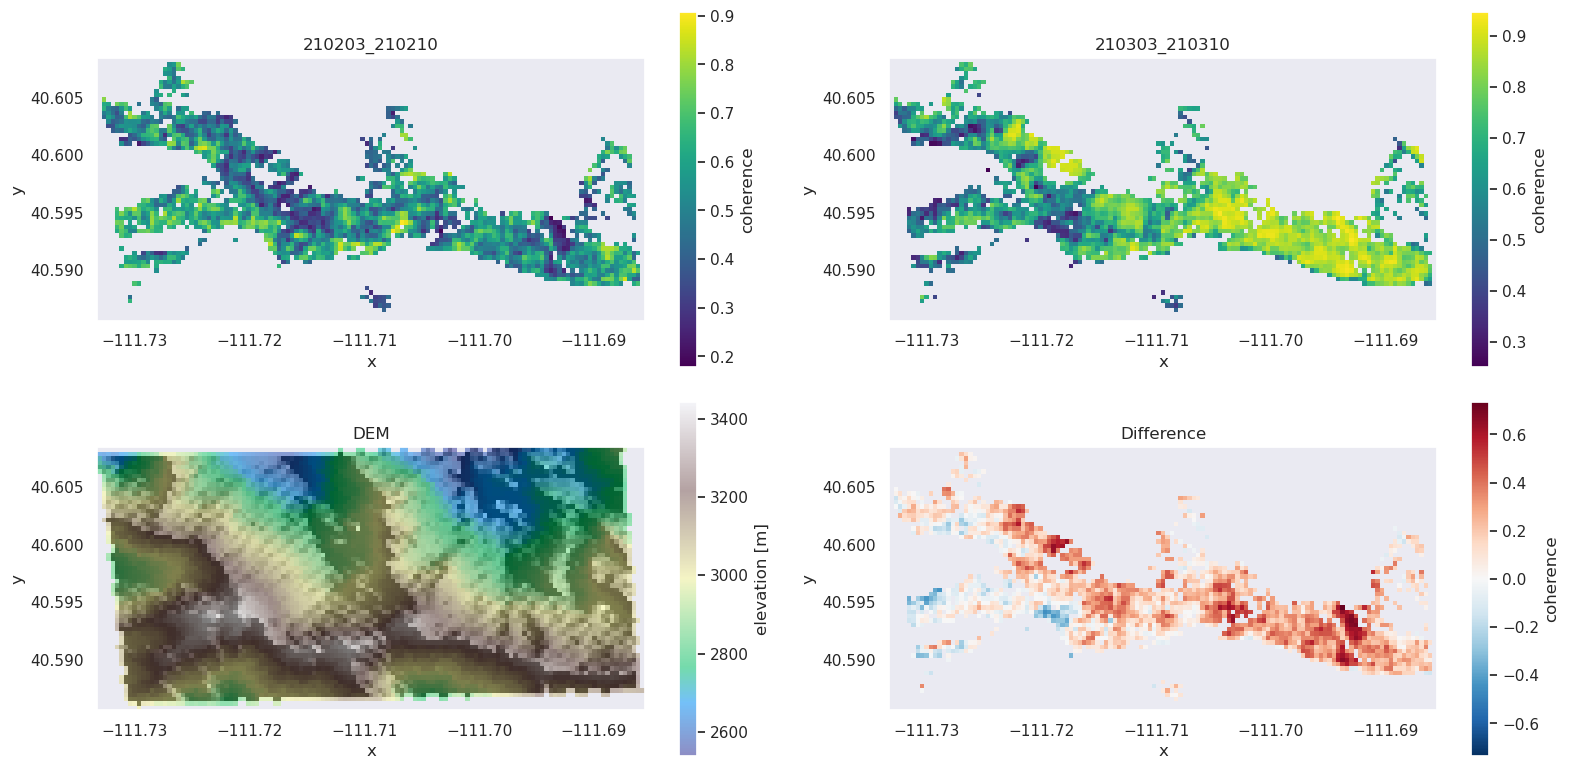

In [35]:
from matplotlib.colors import LightSource

fig, axes = plt.subplots(2, 2, figsize=(16,8))
axes = axes.flatten()

accum['coherence'].plot(ax=axes[0])
axes[0].set_aspect('equal')
axes[0].set_title('210203_210210')
no_accum['coherence'].plot(ax=axes[1])
axes[1].set_aspect('equal')
axes[1].set_title('210303_210310')

ls = LightSource(azdeg=60, altdeg=45)
hillshade = ls.hillshade(slc['elevation'].squeeze().values, vert_exag=1)
dem_shade = slc['elevation'].squeeze().copy(data = hillshade)
hs = dem_shade.plot(ax=axes[2], cmap='gray', add_colorbar=False)
slc['elevation'].plot(ax=axes[2], cmap='terrain', alpha=0.5)
axes[2].set_aspect('equal')
axes[2].set_title('DEM')

diff = no_accum['coherence'] - accum['coherence']
diff.plot(ax=axes[3])
axes[3].set_aspect('equal')
axes[3].set_title('Difference')

plt.tight_layout()
plt.show()


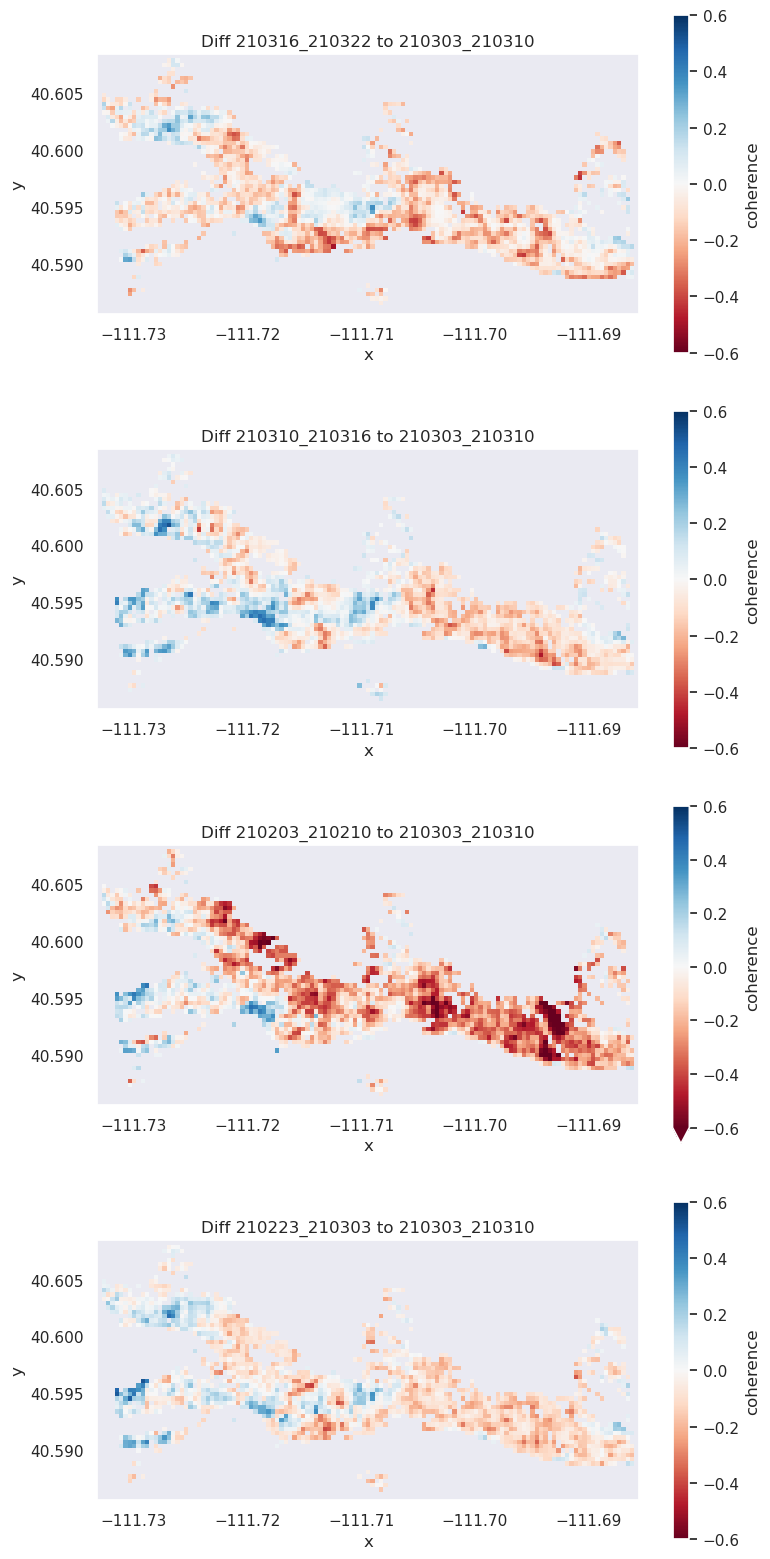

In [36]:
fig, axes = plt.subplots(len(top_3_pairs), 1, figsize=(8, 4*len(top_3_pairs)))
axes = axes.flatten()

for idx, pair_name in enumerate(top_3_pairs):
    diff = slc.sel(pair=pair_name)['coherence'] - no_accum['coherence']
    diff.plot(ax=axes[idx], vmin=-0.6, vmax=0.6, cmap='RdBu')
    axes[idx].set_aspect('equal')
    axes[idx].set_title(f'Diff {pair_name} to 210303_210310')

plt.tight_layout()
plt.show()

# Comparing with modeled SWE and precip 

In [114]:
rmnp_array = rmnp_filtered.to_array(dim='variable')
rmnp_array_flat = rmnp_array.values.reshape(rmnp_array.shape[0], -1).T
rmnp_df = pd.DataFrame(rmnp_array_flat, 
                       columns=[v for v in rmnp_filtered.data_vars])
# rmnp_df

In [115]:
slc_array = slc_filtered.to_array(dim='variable')
slc_array_flat = slc_array.values.reshape(slc_array.shape[0], -1).T
slc_df = pd.DataFrame(slc_array_flat, 
                           columns=[v for v in slc_filtered.data_vars])
# slc_df

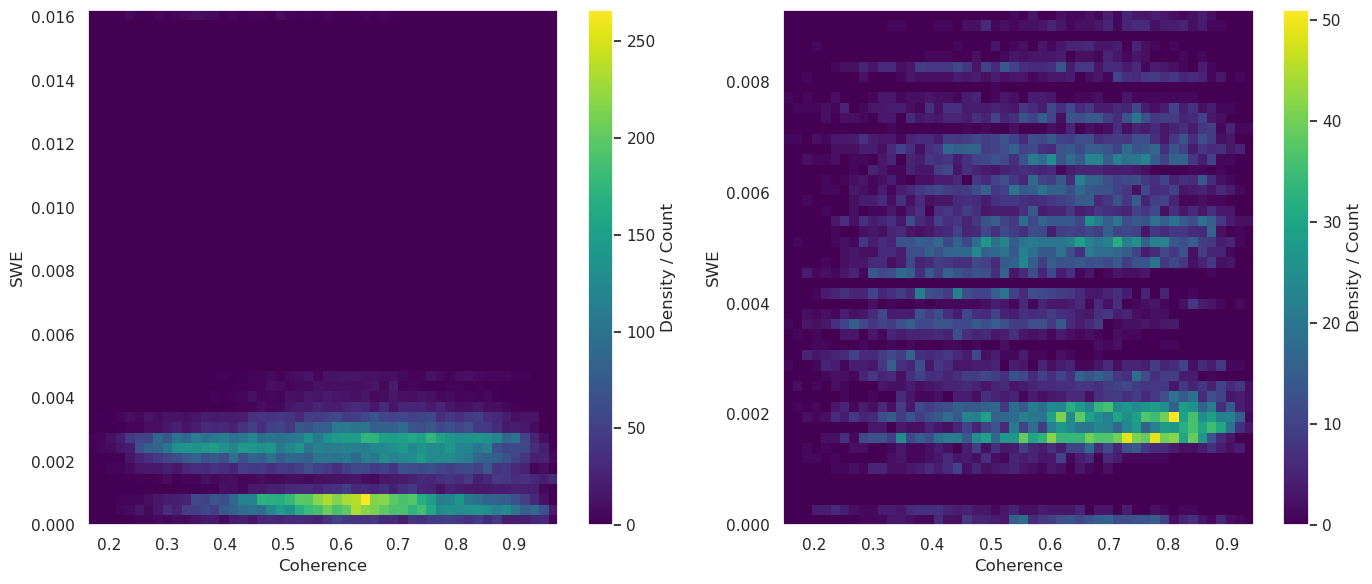

In [116]:
rmnp_clean = rmnp_df[['coherence', 'swe_accum']].dropna()

# 2. Clean slc_df similarly
slc_clean = slc_df[['coherence', 'swe_accum']].dropna()

# Quick sanity check: Ensure we actually have data left to plot
if rmnp_clean.empty or slc_clean.empty:
    raise ValueError("One of the DataFrames is completely empty after dropping NaNs! Check your data loading step.")

# 3. Plot using the cleaned data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap for rmnp_df
h1 = axes[0].hist2d(
    rmnp_clean['coherence'], 
    rmnp_clean['swe_accum'], 
    bins=50, 
    cmap='viridis'
)
axes[0].set_ylabel('SWE')
axes[0].set_xlabel('Coherence')
fig.colorbar(h1[3], ax=axes[0], label='Density / Count')

# Heatmap for slc_df
h2 = axes[1].hist2d(
    slc_clean['coherence'], 
    slc_clean['swe_accum'], 
    bins=50, 
    cmap='viridis'
)
axes[1].set_ylabel('SWE')
axes[1].set_xlabel('Coherence')
fig.colorbar(h2[3], ax=axes[1], label='Density / Count')

plt.tight_layout()
plt.show()

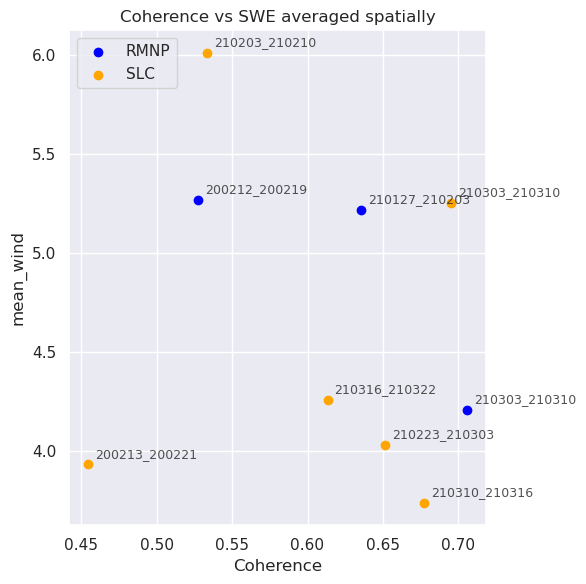

In [120]:
var_name = 'swe_accum'
var_name = 'mean_wind'

fig, axes = plt.subplots(1, 1, figsize=(6, 6))

rmnp_x = rmnp_filtered['coherence'].mean(dim=['x', 'y'])
rmnp_y = rmnp_filtered[var_name].mean(dim=['x', 'y'])

axes.scatter(rmnp_x.values, rmnp_y.values, color='blue', label='RMNP')
axes.set_ylabel(f'{var_name}')
axes.set_xlabel('Coherence')
axes.set_title('Coherence vs SWE averaged spatially')

# Loop through the pairs and annotate
for p in rmnp_filtered['pair'].values:
    x_val = rmnp_x.sel(pair=p).compute().item()
    y_val = rmnp_y.sel(pair=p).compute().item()
    
    axes.annotate(
        text=str(p),             # The text label (pair name)
        xy=(x_val, y_val),       # Point to label
        xytext=(5, 5),           # Offset text by 5 points north-east
        textcoords="offset points", 
        fontsize=9,
        alpha=0.8
    )

# --- Plot 2: SLC ---
# Calculate the means (keeps the 'pair' dimension)
slc_x = slc_filtered['coherence'].mean(dim=['x', 'y'])
slc_y = slc_filtered[var_name].mean(dim=['x', 'y'])

axes.scatter(slc_x.values, slc_y.values, color='orange', label='SLC')

# Loop through the pairs and annotate
for p in slc_filtered['pair'].values:
    x_val = slc_x.sel(pair=p).compute().item()
    y_val = slc_y.sel(pair=p).compute().item()
    
    axes.annotate(
        text=str(p), 
        xy=(x_val, y_val), 
        xytext=(5, 5), 
        textcoords="offset points", 
        fontsize=9,
        alpha=0.8
    )

axes.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [85]:
def map_swe_and_coherence(
    dataset, 
    var_name='swe_accum',
): 
    pair_names = dataset['pair'].values

    for i, p in enumerate(pair_names): 
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes = axes.flatten()

        to_plot = dataset.sel(pair=[p])

        to_plot['coherence'].plot(ax=axes[0], cmap='plasma', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        to_plot[var_name].plot(ax=axes[1], cmap='Blues', cbar_kwargs={'shrink': 0.7})

        axes[0].set_title(f"Average Coherence: {to_plot['coherence'].mean().values:.5f}")
        axes[1].set_title(f"Average {var_name}: {to_plot[var_name].mean().values:.5f}")

        axes[0].set_aspect('equal')
        axes[1].set_aspect('equal')

        axes[0].tick_params(axis='x', labelrotation=45)
        axes[1].tick_params(axis='x', labelrotation=45)

        fig.suptitle(f'Pair: {p}')

        plt.tight_layout()
        plt.show()

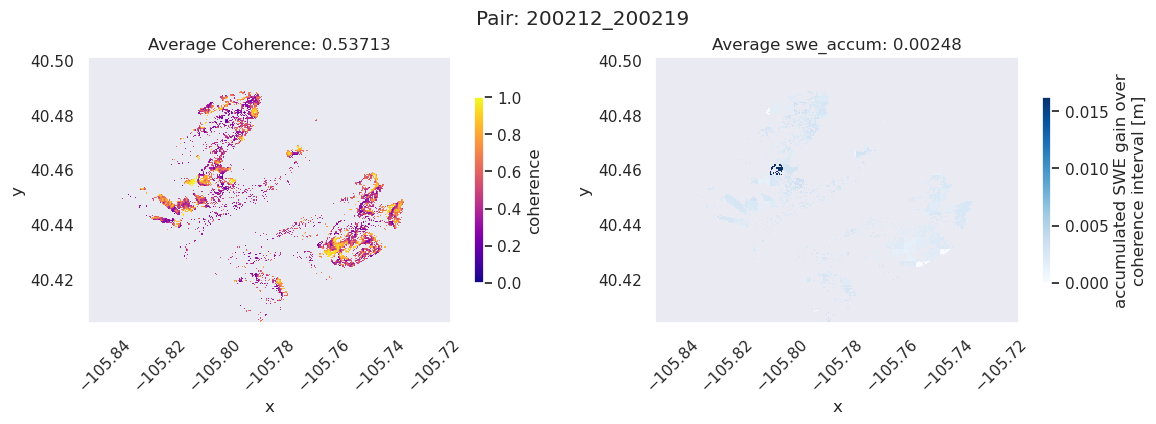

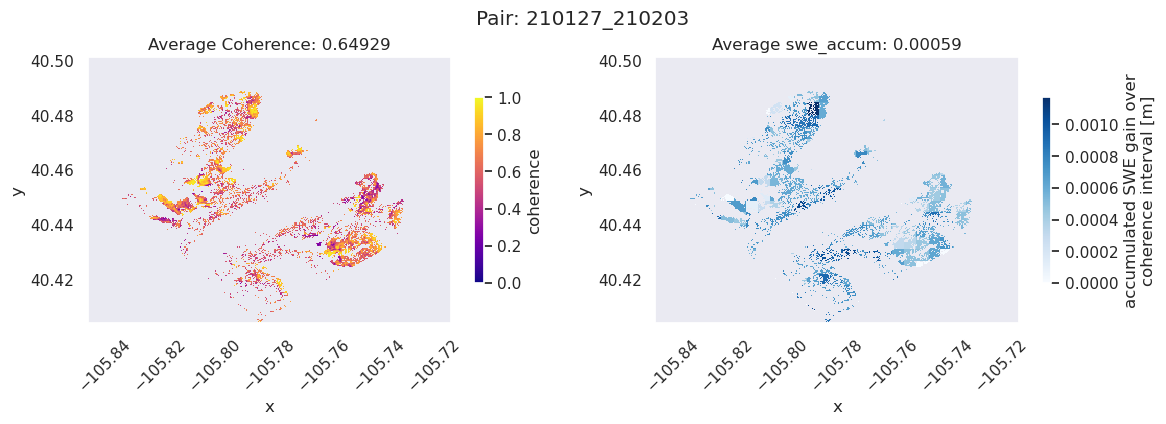

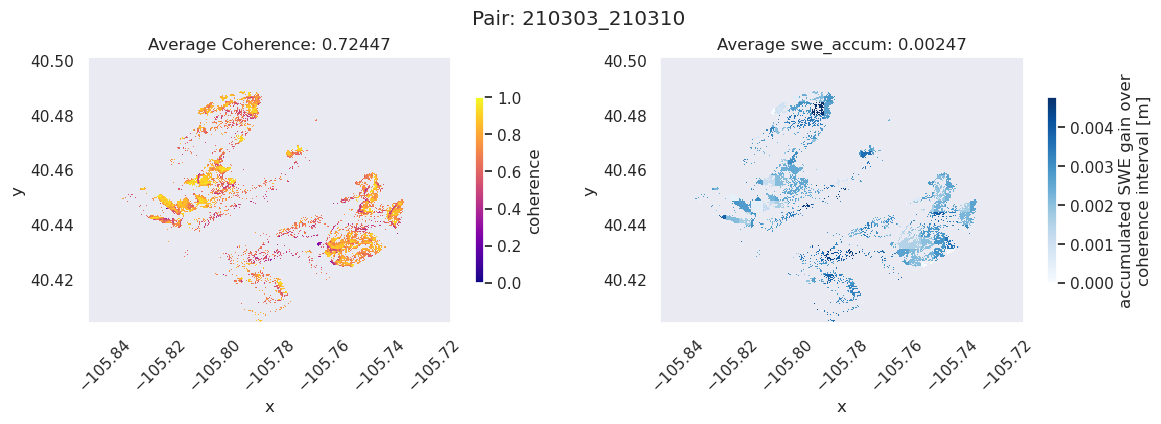

In [86]:
map_swe_and_coherence(rmnp_filtered, 
                      var_name='swe_accum')

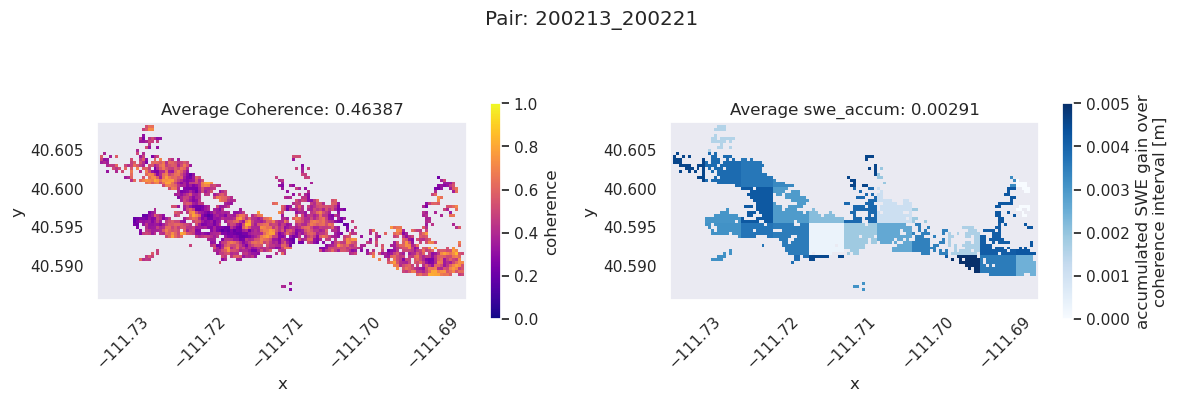

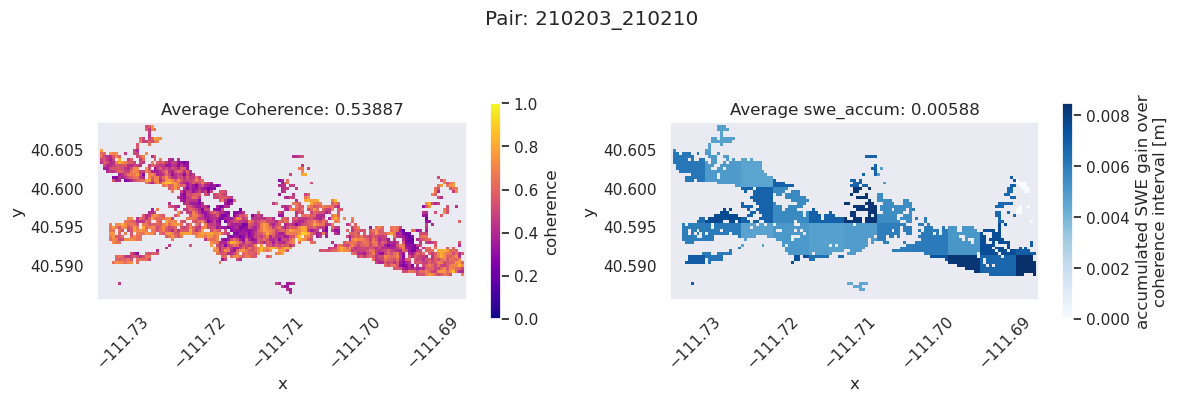

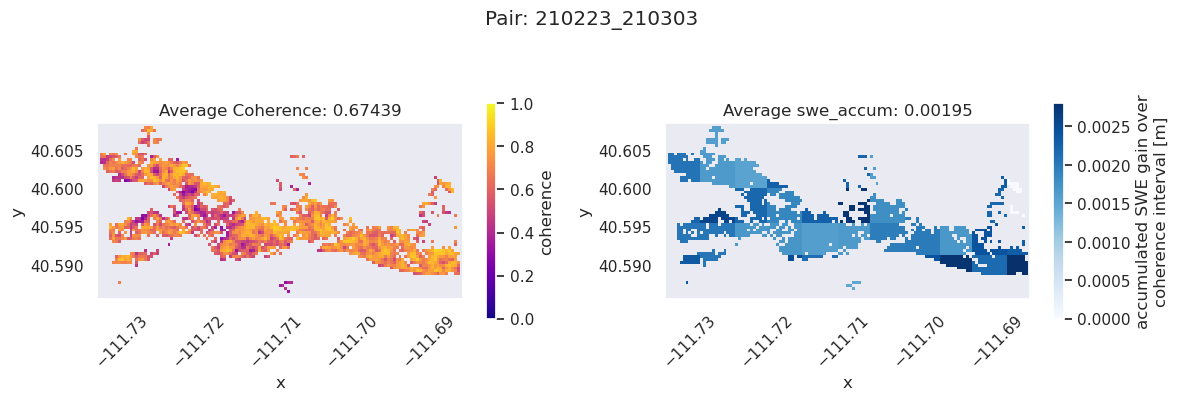

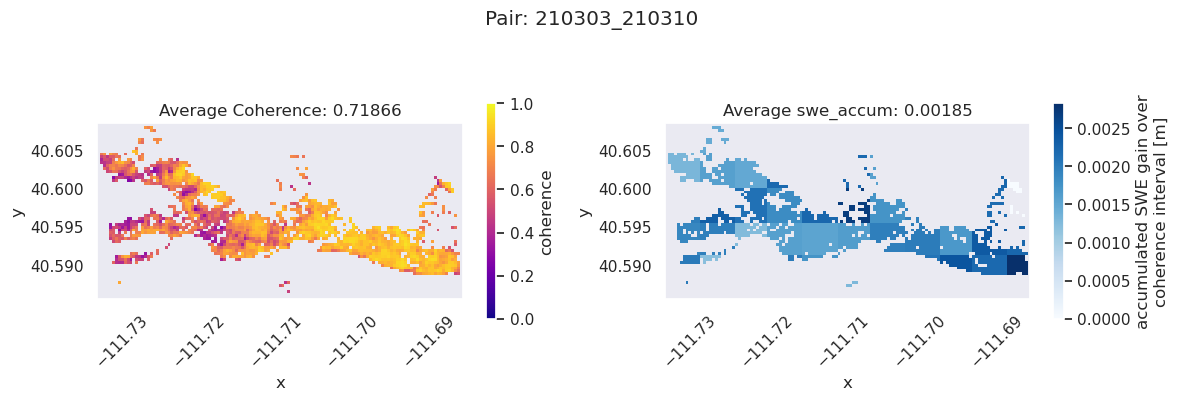

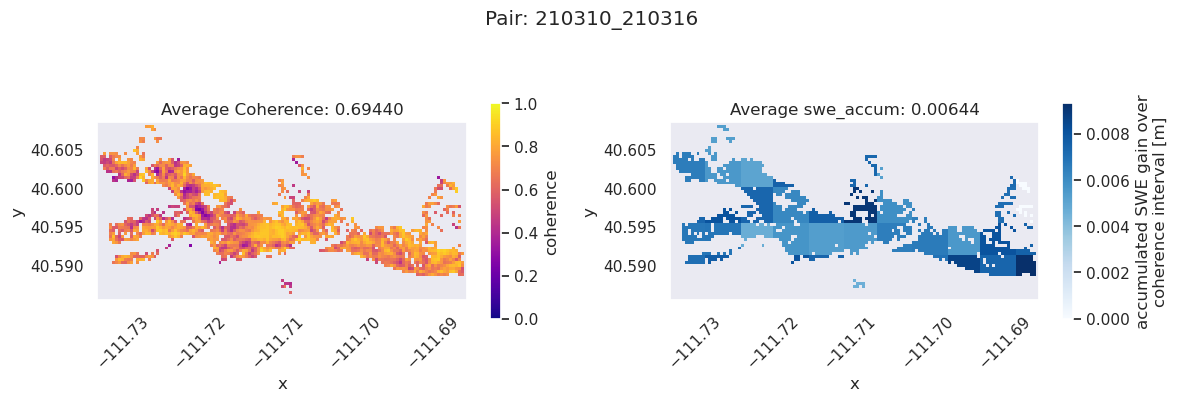

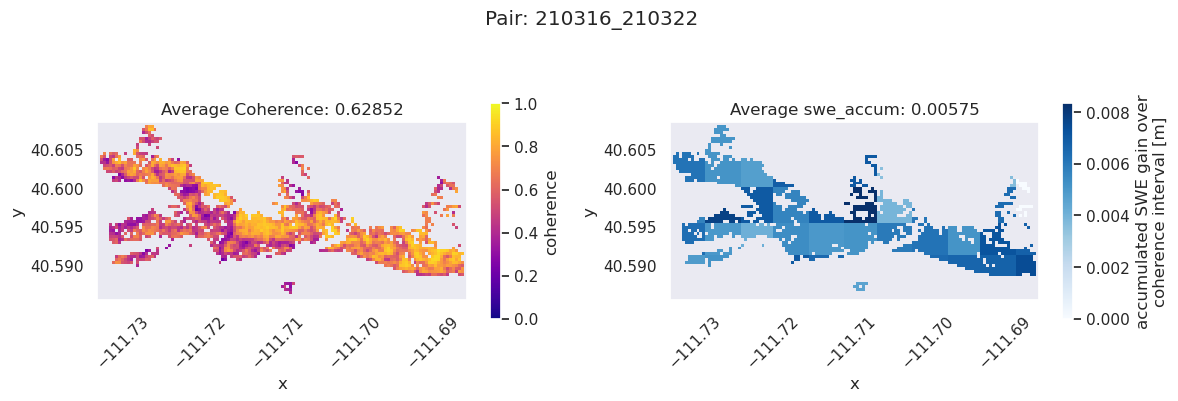

In [87]:
map_swe_and_coherence(slc_filtered, 
                      var_name='swe_accum')